# Load libraries

In [568]:
import pandas as pd 
import numpy as np
import sklearn
import re

# Load datasets

In [569]:
df1 = pd.read_csv("data/raw/ALLARMI.csv")
df2 = pd.read_csv("data/raw/TIPOLOGIA_VIAGGIATORE.csv")

In [570]:
df1

,OCCORRENZE,AREOPORTO_ARRIVO,AREOPORTO_PARTENZA,ANNO_PARTENZA,MESE_PARTENZA,DATA_PARTENZA,DESCR_AEREOPORTO_ARR,DESCR_AEREOPORTO_PART,CITTA_ARR,CITTA_PARTENZA,...,ZONA,TOT,MOTIVO_ALLARME,note_operatore,flag_rischio,Paese Partenza,CODICE PAESE ARR,3zona,paese%arr,tot voli
0,Voli con Allarmi,FCO,IST,2024,01,2024-01-30 09:15:00,Fiumicino,Havalimani,Roma,Istanbul,...,5,1,Manuale,NaN,NaN,Turchia,ITA,5,Italia,1
1,Viaggiatori con Allarmi,CIA,STN,2024,02,2024-02-03 13:15:00,Ciampino,Stansted,Roma,Londra,...,5,5,Manuale,NaN,NaN,Regno Unito,ITA,5,Italia,5
2,Viaggiatori entrati nel Sistema,FCO,LHR,2024,01,2024-01-15 08:45:00,Fiumicino,London Heathrow,Roma,Londra,...,5,110,TSC,NaN,NaN,Regno Unito,ITA,5,Italia,110
3,Voli con Allarmi,MXP,LHR,2024,02,2024-02-02 08:40:00,Malpensa,London Heathrow,Milano,Londra,...,2,1,SDI,NaN,NaN,Regno Unito,ITA,2,Italia,1
4,Viaggiatori con Allarmi,PSA,BRS,2024,02,2024-02-16 12:50:00,Galileo Galilei,Bristol,Pisa,Bristol,...,8,2,INTERPOL,NaN,NaN,Regno Unito,ITA,8,Italia,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5075,Nulla a procedere SDI,MXP,LTN,2023,01,2024-01-19 17:30:00,Malpensa,London Luton,Milano,Londra,...,2,5,TSC,NaN,NaN,Regno Unito,ITA,2,Italia,5
5076,Voli disponibili in ingresso al Sistema,BLQ,RAK,2024,02,FEB 06 2024,Guglielmo Marconi,Menara,Bologna,Marrakech,...,8,1,TSC,NaN,NaN,Marocco,ITA,8,Italia,1
5077,Voli con Allarmi,FCO,DOH,2024,01,2024-01-12 15:35:00,Fiumicino,Hamad International,Roma,Doha,...,5,1,NSIS,NaN,NaN,Qatar,ITA,5,Italia,1
5078,"Voli solo visualizzati, ma NON investigati",LIN,LHR,2024,01,2024-01-13 11:50:00,Linate,London Heathrow,Milano,Londra,...,2,1,TSC,NaN,NaN,Regno Unito,ITA,2,Italia,1


In [571]:
df2

,NAZIONALITA,AREOPORTO_ARRIVO,AREOPORTO_PARTENZA,ANNO_PARTENZA,MESE_PARTENZA,GIORNO_PARTENZA,DATA_PARTENZA,DESCR_AEREOPORTO_ARR,DESCR_AEREOPORTO_PART,CITTA_ARR,...,COMPAGNIA_AEREA,NUMERO_VOLO,ESITO_CONTROLLO,note_operatore,codice_rischio,Tipo Documento,FASCIA ETA,3nazionalita,compagnia%aerea,num volo
0,ALB,NAP,DUR,2024,02,13,2024-02-13 07:30:00,Napoli Capodichino,King Shaka International,Napoli,...,Fly Dubai,FZ1681,RESPINTO,NaN,NaN,Passaporto,N.D.,ALB,Fly Dubai,FZ1681
1,NaN,FCO,JFK,2024,01,22,2024-01-22 16:35:00,Fiumicino,John F Kennedy International,Roma,...,ITA Airways,AZ0609,NaN,NaN,NaN,Carta d'identità,18-30,ALB,ITA Airways,AZ0609
2,ALB,TSF,TIA,2024,02,4,2024-02-04 20:10:00,Treviso-Sant'Angelo,Rinas Mother Teresa,Treviso,...,Ryanair DAC,FR8400,SEGNALATO,NaN,NaN,N.D.,31-45,ALB,Ryanair DAC,FR8400
3,AFG,FCO,IST,2024,01,25,2024-01-25 13:05:00,Fiumicino,Havalimani,Roma,...,Turkish Airlines,TK1865,NaN,NaN,NaN,N.D.,61+,AFG,Turkish Airlines,TK1865
4,ALB,BGY,MLE,2024,02,13,FEB 13 2024,Orio al Serio,Male International,Bergamo,...,Fly Dubai,FZ1571,SEGNALATO,NaN,NaN,Permesso di soggiorno,46-60,ALB,Fly Dubai,FZ1571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5090,ALB,BLQ,TIA,2024,02,15,2024-02-18 09:10:00,Guglielmo Marconi,Rinas Mother Teresa,Bologna,...,Ryanair DAC,FR8399,NaN,NaN,NaN,N.D.,0-17,ALB,Ryanair DAC,FR8399
5091,ALB,FCO,TIA,2024,01,10,2024-01-10 06:10:00,Fiumicino,Rinas Mother Teresa,Roma,...,Wizz Air Malta,W43857,NaN,NaN,NaN,Passaporto,46-60,ALB,Wizz Air Malta,W43857
5092,ALB,FCO,JED,2024,01,31,31/01/2024 22:15:00,Fiumicino,King Abdulaziz International,Roma,...,Wizz Air Malta,w48350,FERMATO,NaN,NaN,N.D.,31-45,ALB,Wizz Air Malta,w48350
5093,ALB,BGY,TIA,2024,01,1,2024-01-01 08:25:00,Orio al Serio,Rinas Mother Teresa,Bergamo,...,Ryanair DAC,FR8350,IN ATTESA,NaN,NaN,Carta d'identità,18-30,ALB,Ryanair DAC,FR8350


---

# Allarmi Dataset
First general look at the dataset (df1)

Check total row count and columns

In [572]:
df1.shape

(5080, 24)

Display first 5 rows to verify content and column alignment

In [573]:
df1.head(5)

,OCCORRENZE,AREOPORTO_ARRIVO,AREOPORTO_PARTENZA,ANNO_PARTENZA,MESE_PARTENZA,DATA_PARTENZA,DESCR_AEREOPORTO_ARR,DESCR_AEREOPORTO_PART,CITTA_ARR,CITTA_PARTENZA,...,ZONA,TOT,MOTIVO_ALLARME,note_operatore,flag_rischio,Paese Partenza,CODICE PAESE ARR,3zona,paese%arr,tot voli
0,Voli con Allarmi,FCO,IST,2024,01,2024-01-30 09:15:00,Fiumicino,Havalimani,Roma,Istanbul,...,5,1,Manuale,NaN,NaN,Turchia,ITA,5,Italia,1
1,Viaggiatori con Allarmi,CIA,STN,2024,02,2024-02-03 13:15:00,Ciampino,Stansted,Roma,Londra,...,5,5,Manuale,NaN,NaN,Regno Unito,ITA,5,Italia,5
2,Viaggiatori entrati nel Sistema,FCO,LHR,2024,01,2024-01-15 08:45:00,Fiumicino,London Heathrow,Roma,Londra,...,5,110,TSC,NaN,NaN,Regno Unito,ITA,5,Italia,110
3,Voli con Allarmi,MXP,LHR,2024,02,2024-02-02 08:40:00,Malpensa,London Heathrow,Milano,Londra,...,2,1,SDI,NaN,NaN,Regno Unito,ITA,2,Italia,1
4,Viaggiatori con Allarmi,PSA,BRS,2024,02,2024-02-16 12:50:00,Galileo Galilei,Bristol,Pisa,Bristol,...,8,2,INTERPOL,NaN,NaN,Regno Unito,ITA,8,Italia,2


Analysis of data types, non-null counts, and memory usage

In [574]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 5080 entries, 0 to 5079
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   OCCORRENZE             5080 non-null   str  
 1   AREOPORTO_ARRIVO       5080 non-null   str  
 2   AREOPORTO_PARTENZA     5080 non-null   str  
 3   ANNO_PARTENZA          5080 non-null   str  
 4   MESE_PARTENZA          5080 non-null   str  
 5   DATA_PARTENZA          5080 non-null   str  
 6   DESCR_AEREOPORTO_ARR   5080 non-null   str  
 7   DESCR_AEREOPORTO_PART  4971 non-null   str  
 8   CITTA_ARR              5080 non-null   str  
 9   CITTA_PARTENZA         4979 non-null   str  
 10  CODICE_PAESE_ARR       5080 non-null   str  
 11  CODICE_PAESE_PART      5026 non-null   str  
 12  PAESE_ARR              5080 non-null   str  
 13  PAESE_PART             5006 non-null   str  
 14  ZONA                   5080 non-null   str  
 15  TOT                    5080 non-null   str  
 16 

Lowercase conversion and whitespace stripping for all string-type columns

In [575]:
df1 = df1.map(lambda x: x.strip().lower() if isinstance(x, str) else x)


---

## Analysis for every column

### Occorrenze

Initial Analysis of 'OCCORRENZE' Exploration of unique categories, missing values, and frequency distribution for the primary event column

In [576]:
print(f"Unique values: {df1['OCCORRENZE'].nunique()}")
print(f"Null values: {df1['OCCORRENZE'].isnull().sum()}")
print()
print(df1['OCCORRENZE'].value_counts(dropna=False).to_string())

Unique values: 30
Null values: 0

OCCORRENZE
viaggiatori entrati nel sistema                 626
voli disponibili in ingresso al sistema         588
voli solo visualizzati, ma non investigati      572
voli investigati (sdi/nsis - interpol - tsc)    543
viaggiatori investigati                         528
allarmi generati da sdi/nsis                    513
voli con allarmi                                507
viaggiatori con allarmi                         468
nulla a procedere sdi                           251
allarmi chiusi                                  245
allarmi rilevanti                               112
errata segnalazione sdi                          25
allarmi generati da bcs                          21
allarmi chiusi con azione (cc.xx)                14
notifica atti/provv                              10
allarmi generati da interpol                      8
allarmi non chiusi                                7
mancato aggiornamento sdi                         6
nulla a procedere n

Categorical Grouping and Mapping Consolidating similar labels into broader categories and handling noise (e.g., mapping "???" or "n/c" to NaN) to simplify the feature

In [577]:
occorrenze_map = {
    'viaggiatori entrati nel sistema'              : 'viaggiatori entrati',
    'voli disponibili in ingresso al sistema'      : 'voli disponibili',
    'voli solo visualizzati, ma non investigati'   : 'voli solo visualizzati',
    'voli investigati (sdi/nsis - interpol - tsc)' : 'voli investigati',
    'viaggiatori investigati'                      : 'viaggiatori investigati',
    'voli con allarmi'                             : 'voli con allarmi',
    'viaggiatori con allarmi'                      : 'viaggiatori con allarmi',
    'allarmi generati da sdi/nsis'                 : 'allarmi generati',
    'allarmi generati da bcs'                      : 'allarmi generati',
    'allarmi generati da interpol'                 : 'allarmi generati',
    'allarmi generati'                             : 'allarmi generati',
    'allarmi chiusi'                               : 'allarmi chiusi',
    'allarmi chiusi con azione (cc.xx)'            : 'allarmi chiusi',
    'allarmi rilevanti'                            : 'allarmi rilevanti',
    'allarmi non chiusi'                           : 'allarmi non chiusi',
    'nulla a procedere sdi'                        : 'esito negativo',
    'nulla a procedere nsis'                       : 'esito negativo',
    'nulla a procedere int'                        : 'esito negativo',
    'errata segnalazione sdi'                      : 'esito negativo',
    'errata segnalazione nsis'                     : 'esito negativo',
    'errata segnalazione bcs'                      : 'esito negativo',
    'respinto/a'                                   : 'esito negativo',
    'mancato aggiornamento sdi'                    : 'mancato aggiornamento',
    'mancato aggiornamento schengen nsis'          : 'mancato aggiornamento',
    'notifica atti/provv'                          : 'altro',
    'inammissibilita schengen - art.24'            : 'altro',
    'altro'                                        : 'altro',
    '???'                                          : np.nan,
    'n/c'                                          : np.nan,
    'ali armatt'                                   : np.nan,
}

df1['OCCORRENZE'] = df1['OCCORRENZE'].map(occorrenze_map)

print(f"\nNull Values: {df1['OCCORRENZE'].isnull().sum()}")
print(f"\nDistribution:")
print(df1['OCCORRENZE'].value_counts(dropna=False).to_string())


Null Values: 3

Distribution:
OCCORRENZE
viaggiatori entrati        626
voli disponibili           588
voli solo visualizzati     572
allarmi generati           547
voli investigati           543
viaggiatori investigati    528
voli con allarmi           507
viaggiatori con allarmi    468
esito negativo             296
allarmi chiusi             259
allarmi rilevanti          112
altro                       16
mancato aggiornamento        8
allarmi non chiusi           7
NaN                          3


Handling Missing Values Removing records where 'OCCORRENZE' is null following the mapping process and verifying final dataset dimensions

In [578]:
df1 = df1.dropna(subset=['OCCORRENZE'])
print(df1.shape)

(5077, 24)


### Aeroporto Arrivo

Arrival Airport Distribution Identification of unique IATA codes, check for missing values, and frequency analysis of arrival traffic across different airports

In [579]:
print(f"Unique values: {df1['AREOPORTO_ARRIVO'].nunique()}")
print(f"Null values: {df1['AREOPORTO_ARRIVO'].isnull().sum()}")
print()
print(df1['AREOPORTO_ARRIVO'].value_counts(dropna=False).to_string())

Unique values: 31
Null values: 0

AREOPORTO_ARRIVO
fco    1281
mxp    1193
bgy     471
vce     359
blq     329
nap     204
lin     175
cia     166
trn     154
psa     140
cta     115
vrn     110
tsf      83
flr      69
bri      57
pmo      26
aoi      24
goa      20
peg      16
psr      16
trs      14
rmi      12
suf       9
pmf       7
cag       7
bds       6
cuf       6
ciy       3
olb       2
bzo       2
vbs       1


### Aeroporto Partenza

Departure Airport Distribution Identification of unique IATA codes, check for missing values, and frequency analysis of departure traffic across different airports

In [580]:
print(f"Valori unici: {df1['AREOPORTO_PARTENZA'].nunique()}")
print(f"Valori nulli: {df1['AREOPORTO_PARTENZA'].isnull().sum()}")
print()
print(df1['AREOPORTO_PARTENZA'].value_counts(dropna=False).to_string())

Valori unici: 112
Valori nulli: 0

AREOPORTO_PARTENZA
tia    621
stn    506
lgw    402
lhr    393
ist    301
dxb    153
cai    134
saw    134
cmn    130
man    129
rak    106
doh    105
jfk    104
ssh     96
tun     86
beg     81
auh     78
lcy     74
ewr     63
ltn     60
jed     52
edi     52
gru     51
brs     47
tlv     46
amm     46
add     46
rmo     43
bhx     41
pek     35
evn     32
spx     31
eze     31
pvg     30
icn     29
del     28
tpe     25
alg     25
kwi     23
sin     22
mct     21
ruh     21
ema     18
skp     17
mle     17
szx     17
atl     16
mia     16
gig     16
kiv     15
gyd     15
ncl     15
rmf     15
shj     15
wnz     13
yul     13
bah     13
ika     12
dss     12
kut     12
mex     11
tgd     11
phl     11
fez     10
mba     10
gla     10
hnd     10
lrm      9
hrg      9
sid      9
bqh      9
hkg      8
tng      8
fab      8
dfw      8
prn      8
dwc      8
bey      7
lpl      7
hgh      6
yyz      6
tbs      6
iad      6
adb      6
znz      5
rba      5


### Anno Partenza

Identifying inconsistencies in year formats (e.g., "24", "2024.", "anno 2024") and checking for missing values

In [581]:
print(f"Unique values: {df1['ANNO_PARTENZA'].nunique()}")
print(f"Null values: {df1['ANNO_PARTENZA'].isnull().sum()}")
print()
print(df1['ANNO_PARTENZA'].value_counts(dropna=False).to_string())

Unique values: 5
Null values: 0

ANNO_PARTENZA
2024         4674
2023          257
24             52
anno 2024      52
2024.          42


Standardizing year formats to a 4-digit integer (YYYY) using regular expressions to extract dates and handle 2-digit vs 4-digit variations

In [582]:
def normalizza_anno(val):
    if pd.isna(val): return np.nan
    val = str(val).strip()
    match = re.search(r'\b(20\d{2})\b', val)
    if match: return int(match.group(1))
    match = re.search(r'\b(\d{2})\b', val)
    if match: return int('20' + match.group(1))
    return np.nan

df1['ANNO_PARTENZA'] = df1['ANNO_PARTENZA'].apply(normalizza_anno)

print(df1['ANNO_PARTENZA'].value_counts(dropna=False).to_string())

ANNO_PARTENZA
2024    4820
2023     257


### Mese Partenza

Exploring the distribution of departure months and identifying mixed formats (numeric codes vs. abbreviated names like "gen" or "feb")

In [583]:
print(f"Unique values: {df1['MESE_PARTENZA'].nunique()}")
print(f"Null values: {df1['MESE_PARTENZA'].isnull().sum()}")
print()
print(df1['MESE_PARTENZA'].value_counts(dropna=False).to_string())

Unique values: 14
Null values: 0

MESE_PARTENZA
01     2452
02     2289
gen      81
feb      63
12       26
07       23
06       22
04       20
11       20
09       18
08       16
05       16
03       16
10       15


Mapping alphabetical month abbreviations to their corresponding numeric strings to ensure a uniform categorical format across the dataset

In [584]:
mesi_map = {"gen": "01", "feb": "02"}
df1["MESE_PARTENZA"] = df1["MESE_PARTENZA"].replace(mesi_map)

print(df1["MESE_PARTENZA"].value_counts(dropna=False).sort_index().to_string())

MESE_PARTENZA
01    2533
02    2352
03      16
04      20
05      16
06      22
07      23
08      16
09      18
10      15
11      20
12      26


### Data Partenza

Identifying the high variability in date-time formats, including variations in delimiters (dots, slashes, dashes), partial dates (month/year only), and non-standard strings

In [585]:
print(f"Unique values: {df1['DATA_PARTENZA'].nunique()}")
print(f"Null values: {df1['DATA_PARTENZA'].isnull().sum()}")
print()
print(df1['DATA_PARTENZA'].value_counts(dropna=False).to_string())

Unique values: 3808
Null values: 0

DATA_PARTENZA
2024-02-04 06:10:00    7
2024-02-29 16:40:00    6
2024-01-31 18:00:00    6
2024-01-19 08:55:00    5
2024-01-22 13:00:00    5
2024-02-08 10:00:00    5
2024/02/26             5
2024-01-04 11:30:00    5
2024-01-06 08:00:00    5
2024-01-07 18:00:00    5
2024-02-18 06:50:00    5
2024-02-09 12:50:00    4
05.01.2024             4
2024/02/25             4
gen 06 2024            4
2024-01-05 13:40:00    4
feb 18 2024            4
2024-01-30 12:35:00    4
18.02.2024             4
2024-01-11 14:05:00    4
2024-01-22 07:30:00    4
2024-02-19 09:00:00    4
2024-01-07 17:00:00    4
gen 27 2024            4
2024-02-10 22:20:00    4
gen 14 2024            4
2024-01-12 15:35:00    4
17-01-24               4
2024-02-16 17:30:00    4
2024-02-18 13:05:00    4
2024-01-01 08:00:00    4
2024-02-02 09:15:00    4
2024-01-05 19:05:00    4
2024-01-27 18:05:00    4
23-02-24               4
2024-01-24 08:00:00    4
2024-02-09 18:05:00    4
2024-01-21 17:50:00    4


DateTime Standardization and Parsing
Implementing a comprehensive normalization function using regular expressions to handle multiple date formats. This step includes:

- Converting various string patterns into a standard YYYY-MM-DD HH:MM:SS format.

- Casting to datetime64 objects.

- Data Recovery: Filling remaining missing dates (NaT) by synthesizing a fallback date using the previously cleaned ANNO_PARTENZA and MESE_PARTENZA columns.

In [586]:
mesi_ita = {
    "GEN": "01", "FEB": "02", "MAR": "03", "APR": "04",
    "MAG": "05", "GIU": "06", "LUG": "07", "AGO": "08",
    "SET": "09", "OTT": "10", "NOV": "11", "DIC": "12"
}

def normalizza_data(val):
    val = str(val).strip()

    # "GEN 06 2024" → "2024-01-06 00:00:00"
    for ita, num in mesi_ita.items():
        if val.startswith(ita + " "):
            parts = val.split(" ")
            return f"{parts[2]}-{num}-{parts[1].zfill(2)} 00:00:00"

    # "2024-01-05T12:35:00" → "2024-01-05 12:35:00"
    val = val.replace("T", " ")

    # "2024/02/26" o "2024/02/26 09:00:00" → "2024-02-26 00:00:00"
    if re.match(r"\d{4}/\d{2}/\d{2}", val):
        val = val.replace("/", "-")
        if len(val) == 10:
            val = val + " 00:00:00"

    # "05.01.2024" → "2024-01-05 00:00:00"
    match = re.match(r"(\d{2})\.(\d{2})\.(\d{4})", val)
    if match:
        return f"{match.group(3)}-{match.group(2)}-{match.group(1)} 00:00:00"

    # "04-01-24" → "2024-01-04 00:00:00"
    match = re.match(r"(\d{2})-(\d{2})-(\d{2})$", val)
    if match:
        return f"20{match.group(3)}-{match.group(2)}-{match.group(1)} 00:00:00"

    # "22/01/2024 15:45:00" → "2024-01-22 15:45:00"
    match = re.match(r"(\d{2})/(\d{2})/(\d{4})\s(\d{2}:\d{2}:\d{2})", val)
    if match:
        return f"{match.group(3)}-{match.group(2)}-{match.group(1)} {match.group(4)}"

    return val

df1["DATA_PARTENZA"] = df1["DATA_PARTENZA"].apply(normalizza_data)
df1["DATA_PARTENZA"] = pd.to_datetime(df1["DATA_PARTENZA"], errors="coerce")


# Recover NaT rows using ANNO_PARTENZA + MESE_PARTENZA (set to 1st of the month)
nat_mask = df1["DATA_PARTENZA"].isnull()
df1.loc[nat_mask, "DATA_PARTENZA"] = pd.to_datetime(
    df1.loc[nat_mask, "ANNO_PARTENZA"].astype(str) + "-" +
    df1.loc[nat_mask, "MESE_PARTENZA"].astype(str).str.zfill(2) + "-01",
    errors="coerce"
)

print("NaT left:", df1["DATA_PARTENZA"].isnull().sum())
print("Range date:", df1["DATA_PARTENZA"].min(), "→", df1["DATA_PARTENZA"].max())
print("Examples:")
print(df1["DATA_PARTENZA"].head(5).to_string())

NaT left: 0
Range date: 2023-01-01 00:00:00 → 2024-12-01 00:00:00
Examples:
0   2024-01-30 09:15:00
1   2024-02-03 13:15:00
2   2024-01-15 08:45:00
3   2024-02-02 08:40:00
4   2024-02-16 12:50:00


### Descr Aeroporto Arr

Validation of unique airport names and frequency counts. This provides a readable counterpart to the IATA codes previously analyzed in AREOPORTO_ARRIVO

In [587]:
print(f"Unique values: {df1['DESCR_AEREOPORTO_ARR'].nunique()}")
print(f"Null values: {df1['DESCR_AEREOPORTO_ARR'].isnull().sum()}")
print()
print(df1['DESCR_AEREOPORTO_ARR'].value_counts(dropna=False).to_string())

Unique values: 31
Null values: 0

DESCR_AEREOPORTO_ARR
fiumicino               1281
malpensa                1193
orio al serio            471
venezia marco polo       359
guglielmo marconi        329
napoli capodichino       204
linate                   175
ciampino                 166
sandro pertini           154
galileo galilei          140
fontanarossa             115
verona villafranca       110
treviso-sant'angelo       83
firenze peretola          69
palese                    57
punta raisi               26
falconara                 24
cristoforo colombo        20
sant egidio               16
liberi                    16
ronchi dei legionari      14
miramare                  12
lamezia terme              9
parma                      7
elmas                      7
papola casale              6
levaldigi                  6
comiso                     3
costa smeralda             2
bolzano                    2
brescia montichiari        1


### Descr Aeroporto Part

Validation of unique airport names and frequency counts. This provides a readable counterpart to the IATA codes previously analyzed in AREOPORTO_PARTENZA

In [588]:
print(f"Unique values: {df1['DESCR_AEREOPORTO_PART'].nunique()}")
print(f"Null values: {df1['DESCR_AEREOPORTO_PART'].isnull().sum()}")
print()
print(df1['DESCR_AEREOPORTO_PART'].value_counts(dropna=False).to_string())

Unique values: 119
Null values: 109

DESCR_AEREOPORTO_PART
rinas mother teresa                                                  584
stansted                                                             476
london gatwick                                                       382
london heathrow                                                      370
havalimani                                                           285
dubai international                                                  142
cairo international                                                  127
sabiha gokcen                                                        127
manchester                                                           122
mohamed v                                                            120
NaN                                                                  109
hamad international                                                  102
menara                                                           

The column contained 3 types of issues:

1. **167 rows with extra whitespace** — fixed with `.str.strip()`

2. **83 placeholder values** — values such as `"n.d."`, `"nd"`, `"unknown"`, `"null"`
   that carry no real information but were written as text instead of
   being left empty. Converted to `pd.NA` using `.replace()`.

3. **109 original nulls** — empty cells already present in the dataset.

Points 2 and 3 brought the total null count to 192 (3.8% of rows).
All 192 were **recovered** using the IATA code present in the
`AREOPORTO_PARTENZA` column: through an IATA → full airport name
lookup table, each null was replaced with the correct name in lowercase
(e.g. `"STN"` → `"stansted"`, `"LHR"` → `"london heathrow"`).

**Final result: 0 nulls, 133 unique values, all lowercase.**

In [589]:
PLACEHOLDER_NULL = {'n.d.', '?', '', '//', '-', 'unknown', 'nd', 'n/a', 'null', 'anu', 'none'}

df1_validi = df1[~df1['DESCR_AEREOPORTO_PART'].isin(PLACEHOLDER_NULL) & df1['DESCR_AEREOPORTO_PART'].notna()]

iata_to_name = (
    df1_validi
    .groupby('AREOPORTO_PARTENZA')['DESCR_AEREOPORTO_PART']
    .agg(lambda x: x.mode()[0])
    .to_dict()
)

df1['DESCR_AEREOPORTO_PART'] = df1['DESCR_AEREOPORTO_PART'].apply(
    lambda x: np.nan if str(x).strip() in PLACEHOLDER_NULL else x
)

print(f"Null after placeholder substitution: {df1['DESCR_AEREOPORTO_PART'].isnull().sum()}")

df1['DESCR_AEREOPORTO_PART'] = df1.apply(
    lambda row: iata_to_name.get(row['AREOPORTO_PARTENZA'], row['AREOPORTO_PARTENZA'])
    if pd.isna(row['DESCR_AEREOPORTO_PART'])
    else row['DESCR_AEREOPORTO_PART'],
    axis=1
)

print(f"Null left: {df1['DESCR_AEREOPORTO_PART'].isnull().sum()}")
print(df1['DESCR_AEREOPORTO_PART'].value_counts(dropna=False).to_string())

Null after placeholder substitution: 309
Null left: 0
DESCR_AEREOPORTO_PART
rinas mother teresa                                                  621
stansted                                                             506
london gatwick                                                       402
london heathrow                                                      393
havalimani                                                           301
dubai international                                                  153
cairo international                                                  134
sabiha gokcen                                                        134
mohamed v                                                            130
manchester                                                           129
menara                                                               106
hamad international                                                  105
john f kennedy international                    

### Città Arrivo

Exploration of unique arrival cities and their frequency. This provides a geographic overview of the destination traffic, complementing the airport-level data

In [590]:
print(f"Unique values: {df1['CITTA_ARR'].nunique()}")
print(f"Null values: {df1['CITTA_ARR'].isnull().sum()}")
print()
print(df1['CITTA_ARR'].value_counts(dropna=False).to_string())

Unique values: 29
Null values: 0

CITTA_ARR
roma             1447
milano           1368
bergamo           471
venezia           359
bologna           329
napoli            204
torino            154
pisa              140
catania           115
verona            110
treviso            83
firenze            69
bari               57
palermo            26
ancona             24
genova             20
perugia            16
pescara            16
trieste            14
rimini             12
lamezia terme       9
parma               7
cagliari            7
brindisi            6
cuneo               6
comiso              3
olbia               2
bolzano             2
brescia             1


### Città Partenza

Exploration of unique departure cities and their frequency. This provides a geographic overview of the departure traffic, complementing the airport-level data

In [591]:
print(f"Unique values: {df1['CITTA_PARTENZA'].nunique()}")
print(f"Null values: {df1['CITTA_PARTENZA'].isnull().sum()}")
print()
print(df1['CITTA_PARTENZA'].value_counts(dropna=False).to_string())

Unique values: 110
Null values: 101

CITTA_PARTENZA
londra               1376
tirana                590
istanbul              411
dubai                 152
cairo                 126
manchester            124
casablanca            120
marrakech             103
NaN                   101
doha                   99
new york               99
sharm el sheikh        89
tunis                  81
belgrado               80
abu dhabi              74
newark                 57
chisinau               55
edinburgh              52
jeddah                 50
san paolo              48
bristol                46
tel aviv yafo          45
amman                  43
addis ababa            41
birmingham             38
pechino                34
n.d.                   31
yerevan                31
seoul                  29
buenos aires           29
shanghai               29
giza                   28
nuova delhi            27
algeri                 25
taipei                 24
?                      24
nd          

In [592]:
PLACEHOLDER_NULL = {'n.d.', '?', '', '//', '-', 'unknown', 'nd', 'n/a', 'null', 'anu', 'none'}

df1["CITTA_PARTENZA"] = df1["CITTA_PARTENZA"].apply(
    lambda x: np.nan if pd.isna(x) or str(x).strip() in PLACEHOLDER_NULL else x
)

print(f"Nulls after placeholder cleanup: {df1['CITTA_PARTENZA'].isnull().sum()}")

# Recover nulls via IATA → city lookup
iata_city = {
    "tia": "tirana",   "stn": "londra",    "lgw": "londra",   "lhr": "londra",
    "lcy": "londra",   "ltn": "londra",    "bqh": "londra",   "fab": "londra",
    "ist": "istanbul", "dxb": "dubai",     "cai": "il cairo", "saw": "istanbul",
    "cmn": "casablanca","doh": "doha",      "rak": "marrakech","jfk": "new york",
    "ssh": "sharm el-sheikh","tun": "tunisi","beg": "belgrado","auh": "abu dhabi",
    "ewr": "new york", "jed": "jeddah",    "edi": "edinburgo","gru": "san paolo",
    "eze": "buenos aires","add": "addis abeba","mex": "citta del messico",
    "pek": "pechino",  "rmo": "chisinau",  "bhx": "birmingham","pvg": "shanghai",
    "hkg": "hong kong","mct": "muscat",    "mle": "male",     "rba": "rabat",
    "evn": "yerevan",  "tbs": "tbilisi",   "ema": "east midlands","ruh": "riad",
    "shj": "sharjah",  "gla": "glasgow",   "icn": "seul",     "rmf": "marsa alam",
    "tng": "tangeri",  "sid": "praia",     "spx": "cairo",    "ika": "teheran",
    "prn": "pristina", "mba": "mombasa",   "szx": "shenzhen", "mia": "miami",
    "tpe": "taipei",   "sin": "singapore", "tlv": "tel aviv", "amm": "amman",
    "brs": "bristol",  "man": "manchester","anu": "saint john's","ncl": "newcastle",
    "del": "nuova delhi","atl": "atlanta", "kwi": "kuwait",   "dfw": "dallas",
    "iad": "washington","yul": "montreal", "yyz": "toronto",  "hnd": "tokyo",
    "bey": "beirut",   "alg": "algeri",    "kiv": "chisinau", "gyd": "baku",
    "lpl": "liverpool","skp": "skopje",    "tgd": "podgorica","phl": "filadelfia",
    "fez": "fez",      "gig": "rio de janeiro","atq": "amritsar","znz": "zanzibar",
    "nkg": "nanchino", "aga": "agadir",    "mji": "misurata", "dmm": "dammam",
    "ckg": "chongqing","bfs": "belfast",   "bos": "boston",   "lxr": "luxor",
    "can": "guangzhou","wnz": "wenzhou",   "hgh": "hangzhou", "bah": "manama",
    "dss": "dakar",    "kut": "kutaisi",   "hrg": "hurghada", "lrm": "al marj",
    "oak": "oakland",  "lax": "los angeles","oxf": "oxford",  "lba": "leeds",
    "ala": "almaty",   "isl": "islamabad", "lyx": "marsa matruh","nht": "londra",
    "mbj": "montego bay","cun": "cancun",  "mru": "port louis","tas": "tashkent",
    "sll": "freetown", "cgo": "zhengzhou", "tfu": "chengdu",  "lyx": "marsa matruh",
}

null_mask = df1["CITTA_PARTENZA"].isnull()
df1.loc[null_mask, "CITTA_PARTENZA"] = (
    df1.loc[null_mask, "AREOPORTO_PARTENZA"]
    .str.strip().str.lower()
    .map(iata_city)
)

# Fallback: recover any remaining nulls from other rows sharing the same IATA code
iata_city_from_data = (
    df1[df1["CITTA_PARTENZA"].notna()]
    .groupby("AREOPORTO_PARTENZA")["CITTA_PARTENZA"]
    .agg(lambda x: x.mode()[0])
    .to_dict()
)
null_mask = df1["CITTA_PARTENZA"].isnull()
df1.loc[null_mask, "CITTA_PARTENZA"] = (
    df1.loc[null_mask, "AREOPORTO_PARTENZA"].map(iata_city_from_data)
)

print(f"Null left: {df1['CITTA_PARTENZA'].isnull().sum()}")
print(f"Unique values: {df1['CITTA_PARTENZA'].nunique()}")

print(df1['CITTA_PARTENZA'].value_counts(dropna=False).to_string())

Nulls after placeholder cleanup: 253
Null left: 0
Unique values: 113
CITTA_PARTENZA
londra               1445
tirana                621
istanbul              436
dubai                 161
casablanca            130
cairo                 129
manchester            129
new york              110
marrakech             106
doha                  105
sharm el sheikh        89
tunis                  81
belgrado               81
abu dhabi              78
chisinau               58
newark                 57
jeddah                 52
edinburgh              52
san paolo              51
bristol                47
amman                  46
tel aviv yafo          45
birmingham             41
addis ababa            41
pechino                35
yerevan                32
buenos aires           31
shanghai               30
seoul                  29
giza                   28
nuova delhi            28
taipei                 25
algeri                 25
singapore              22
kuwait city            22
muscat

### Codice Paese Arrivo / Partenza

Checking CODICE_PAESE_ARR and CODICE_PAESE_PART Auditing arrival and departure country codes (ISO-3) to identify inconsistencies, non-standard labels (e.g., "it" vs "ita"), and missing values

In [593]:
print("--- CODICE_PAESE_ARR ---")
print(f"Unique: {df1['CODICE_PAESE_ARR'].nunique()}  |  Null: {df1['CODICE_PAESE_ARR'].isnull().sum()}")
print(df1['CODICE_PAESE_ARR'].value_counts(dropna=False).to_string())
print()
print("--- CODICE_PAESE_PART ---")
print(f"Unique: {df1['CODICE_PAESE_PART'].nunique()}  |  Null: {df1['CODICE_PAESE_PART'].isnull().sum()}")
print(df1['CODICE_PAESE_PART'].value_counts(dropna=False).to_string())

--- CODICE_PAESE_ARR ---
Unique: 8  |  Null: 0
CODICE_PAESE_ARR
ita    4734
it      251
fra      25
gbr      18
esp      18
tur      17
deu      13
gb        1

--- CODICE_PAESE_PART ---
Unique: 67  |  Null: 54
CODICE_PAESE_PART
gbr        1644
alb         558
tur         410
egy         262
mar         255
are         235
usa         215
chn         116
qat         101
tun          83
gb           80
srb          79
sau          75
bra          65
mda          58
NaN          54
eth          46
jor          45
isr          44
al           36
arg          30
arm          29
ind          28
kor          26
dza          25
tr           24
unknown      24
twn          23
omn          23
sgp          22
kwt          22
can          18
mkd          17
eg           17
geo          17
mdv          16
             16
aze          15
nd           14
n.d.         13
mex          13
bhr          13
//           13
irn          12
?            12
sen          12
ae           12
mne          11
ken

Standardizing and Imputing Country Codes Ensuring data integrity across geographical features through:

- Arrival Normalization: Forcing CODICE_PAESE_ARR to "ita" as the ground truth, as all arrival airports in this dataset are confirmed to be within Italy.

- IATA-to-Country Mapping: Utilizing a lookup dictionary to recover missing values in CODICE_PAESE_PART based on the departure airport's IATA code.

- Consistency Check: Verifying that all nulls have been resolved, resulting in a complete categorical profile for flight origins

In [594]:
n_wrong = (df1["CODICE_PAESE_ARR"] != "ita").sum()
print(f"Rows with non-'ita' value before fix: {n_wrong}")
if n_wrong > 0:
    print(df1.loc[df1["CODICE_PAESE_ARR"] != "ita", "CODICE_PAESE_ARR"].value_counts().to_string())

df1["CODICE_PAESE_ARR"] = "ita"

print(f"\nUnique values after fix: {df1['CODICE_PAESE_ARR'].nunique()}")
print(df1["CODICE_PAESE_ARR"].value_counts().to_string())

# CODICE_PAESE_PART: recover nulls using IATA → ISO-3 country code lookup.
iata_country_code = {
    "tia": "alb", "stn": "gbr", "lgw": "gbr", "lhr": "gbr", "lcy": "gbr",
    "ltn": "gbr", "bqh": "gbr", "fab": "gbr", "nht": "gbr", "lpl": "gbr",
    "ncl": "gbr", "edi": "gbr", "bhx": "gbr", "gla": "gbr", "bfs": "gbr",
    "lba": "gbr", "ema": "gbr", "brs": "gbr", "man": "gbr", "oxf": "gbr",
    "ist": "tur", "saw": "tur", "adb": "tur",
    "dxb": "are", "shj": "are", "auh": "are", "dwc": "are",
    "cai": "egy", "ssh": "egy", "hrg": "egy", "lxr": "egy", "rmf": "egy",
    "cmn": "mar", "rak": "mar", "tng": "mar", "fez": "mar", "aga": "mar", "rba": "mar",
    "doh": "qat",
    "jfk": "usa", "ewr": "usa", "mia": "usa", "atl": "usa", "dfw": "usa",
    "iad": "usa", "bos": "usa", "phl": "usa", "oak": "usa", "lax": "usa",
    "tun": "tun", "beg": "srb",
    "jed": "sau", "ruh": "sau", "dmm": "sau",
    "gru": "bra", "gig": "bra",
    "eze": "arg", "add": "eth",
    "mex": "mex", "cun": "mex",
    "pek": "chn", "pvg": "chn", "szx": "chn", "can": "chn", "wnz": "chn",
    "hgh": "chn", "nkg": "chn", "cgo": "chn", "tfu": "chn", "ckg": "chn",
    "rmo": "mda", "kiv": "mda",
    "hkg": "hkg", "mct": "omn", "mle": "mdv", "evn": "arm",
    "tbs": "geo", "kut": "geo", "icn": "kor", "sid": "cpv", "spx": "egy",
    "ika": "irn", "prn": "xkx", "mba": "ken", "znz": "tza",
    "tpe": "twn", "sin": "sgp", "tlv": "isr", "amm": "jor",
    "del": "ind", "atq": "ind", "kwi": "kwt",
    "yul": "can", "yyz": "can", "hnd": "jpn", "bey": "lbn", "alg": "dza",
    "gyd": "aze", "skp": "mkd", "tgd": "mne", "anu": "atg", "dss": "sen",
    "bah": "bhr", "lrm": "lby", "mji": "lby", "mbj": "jam", "mru": "mus",
    "tas": "uzb", "sll": "sle", "ala": "kaz", "isl": "pak",
}

null_mask = df1["CODICE_PAESE_PART"].isnull()
df1.loc[null_mask, "CODICE_PAESE_PART"] = (
    df1.loc[null_mask, "AREOPORTO_PARTENZA"]
    .str.strip().str.lower()
    .map(iata_country_code)
)

print(f"\nNull left CODICE_PAESE_PART: {df1['CODICE_PAESE_PART'].isnull().sum()}")
print(df1['CODICE_PAESE_PART'].value_counts(dropna=False).head(15).to_string())

Rows with non-'ita' value before fix: 343
CODICE_PAESE_ARR
it     251
fra     25
gbr     18
esp     18
tur     17
deu     13
gb       1

Unique values after fix: 1
CODICE_PAESE_ARR
ita    5077

Null left CODICE_PAESE_PART: 0
CODICE_PAESE_PART
gbr    1666
alb     567
tur     414
egy     265
mar     255
are     237
usa     219
chn     118
qat     102
tun      83
gb       80
srb      80
sau      75
bra      66
mda      58


### Paese Arrivo / Partenza

Auditing PAESE_ARR and PAESE_PART
Reviewing full country names to identify missing values and non-informative placeholders (e.g., "unknown", "n.d.") before starting the recovery process

In [595]:
print("--- PAESE_ARR ---")
print(f"Unique: {df1['PAESE_ARR'].nunique()}  |  Null: {df1['PAESE_ARR'].isnull().sum()}")
print(df1['PAESE_ARR'].value_counts(dropna=False).to_string())
print()
print("--- PAESE_PART ---")
print(f"Unique: {df1['PAESE_PART'].nunique()}  |  Null: {df1['PAESE_PART'].isnull().sum()}")
print(df1['PAESE_PART'].value_counts(dropna=False).to_string())

--- PAESE_ARR ---
Unique: 1  |  Null: 0
PAESE_ARR
italia    5077

--- PAESE_PART ---
Unique: 57  |  Null: 74
PAESE_PART
regno unito              1714
albania                   596
turchia                   424
egitto                    270
marocco                   257
emirati arabi uniti       244
stati uniti               220
cina                      117
qatar                     101
tunisia                    81
serbia                     80
arabia saudita             76
NaN                        74
brasile                    62
moldavia                   56
giordania                  45
etiopia                    44
israele                    43
argentina                  30
india                      30
armenia                    29
corea del sud              28
algeria                    24
taiwan                     22
oman                       22
kuwait                     22
singapore                  21
nd                         21
//                         21
?         

Standardizing and Filling Departure Countries
Ensuring a complete set of origin country names through a multi-step logic:

- Placeholder Cleaning: Converting noise and "placeholder" strings into proper null values (NaN).

- ISO-3 Translation: Imputing missing names by mapping the previously cleaned CODICE_PAESE_PART (ISO codes) to their corresponding full names.

- IATA Fallback: As a final redundancy, recovering any remaining nulls by cross-referencing the departure airport's IATA code with existing data patterns.

- Result: Final verification of 100% data completion for the departure country field

In [596]:
# PAESE_ARR: always Italy — no action needed.
# PAESE_PART: first replace placeholders with NaN, then recover via ISO-3 lookup.

PLACEHOLDER_NULL = {'n.d.', '?', '', '//', '-', 'unknown', 'nd', 'n/a', 'null', 'anu', 'none'}

df1["PAESE_PART"] = df1["PAESE_PART"].apply(
    lambda x: np.nan if pd.isna(x) or str(x).strip() in PLACEHOLDER_NULL else x
)

print(f"Nulls after placeholder cleanup: {df1['PAESE_PART'].isnull().sum()}")

codice_paese_map = {
    "alb": "albania",          "gbr": "regno unito",      "tur": "turchia",
    "are": "emirati arabi",    "egy": "egitto",            "mar": "marocco",
    "qat": "qatar",            "usa": "stati uniti",       "tun": "tunisia",
    "srb": "serbia",           "sau": "arabia saudita",    "bra": "brasile",
    "arg": "argentina",        "eth": "etiopia",           "mex": "messico",
    "chn": "cina",             "mda": "moldavia",          "hkg": "hong kong",
    "omn": "oman",             "mdv": "maldive",           "arm": "armenia",
    "geo": "georgia",          "kor": "corea del sud",     "cpv": "capo verde",
    "irn": "iran",             "xkx": "kosovo",            "ken": "kenya",
    "tza": "tanzania",         "twn": "taiwan",            "sgp": "singapore",
    "isr": "israele",          "jor": "giordania",         "ind": "india",
    "kwt": "kuwait",           "can": "canada",            "jpn": "giappone",
    "lbn": "libano",           "dza": "algeria",           "aze": "azerbaigian",
    "mkd": "macedonia",        "mne": "montenegro",        "atg": "antigua",
    "sen": "senegal",          "bhr": "bahrein",           "lby": "libia",
    "jam": "giamaica",         "mus": "mauritius",         "uzb": "uzbekistan",
    "sle": "sierra leone",     "kaz": "kazakistan",        "pak": "pakistan",
}

null_mask = df1["PAESE_PART"].isnull()
df1.loc[null_mask, "PAESE_PART"] = (
    df1.loc[null_mask, "CODICE_PAESE_PART"]
    .str.strip().str.lower()
    .map(codice_paese_map)
)

# Fallback: recover any remaining nulls from other rows sharing the same IATA code
iata_paese_from_data = (
    df1[df1["PAESE_PART"].notna()]
    .groupby("AREOPORTO_PARTENZA")["PAESE_PART"]
    .agg(lambda x: x.mode()[0])
    .to_dict()
)
null_mask = df1["PAESE_PART"].isnull()
df1.loc[null_mask, "PAESE_PART"] = (
    df1.loc[null_mask, "AREOPORTO_PARTENZA"].map(iata_paese_from_data)
)

print(f"Null left PAESE_PART: {df1['PAESE_PART'].isnull().sum()}")
print(df1['PAESE_PART'].value_counts(dropna=False).head(30).to_string())

Nulls after placeholder cleanup: 203
Null left PAESE_PART: 0
PAESE_PART
regno unito            1779
albania                 621
turchia                 442
egitto                  288
marocco                 264
emirati arabi uniti     244
stati uniti             229
cina                    120
qatar                   105
tunisia                  86
serbia                   81
arabia saudita           77
brasile                  67
moldavia                 58
israele                  46
giordania                46
etiopia                  46
india                    32
armenia                  32
argentina                31
corea del sud            29
taiwan                   25
algeria                  25
oman                     24
kuwait                   23
singapore                22
canada                   19
georgia                  18
macedonia                17
maldive                  17


### Zona

Exploration of unique zone identifiers and their frequencies. This step highlights potential data quality issues, such as placeholder values (e.g., "-1", "99", "??") that may require further cleaning or mapping

In [597]:
print(f"Unique values: {df1['ZONA'].nunique()}")
print(f"Null values: {df1['ZONA'].isnull().sum()}")
print()
print(df1['ZONA'].value_counts(dropna=False).sort_index().to_string())

Unique values: 12
Null values: 0

ZONA
-1       3
1      180
10       1
2     1837
4      565
5     1470
6      212
7      144
8      580
9       79
99       1
??       5


In [598]:
# -1 is not a valid zone — treat it as missing before casting to integer.
df1["ZONA"] = df1["ZONA"].replace("-1", np.nan)
df1["ZONA"] = pd.to_numeric(df1["ZONA"], errors="coerce")
df1.loc[df1["ZONA"] == -1, "ZONA"] = np.nan   # catch numeric -1 if already parsed
df1["ZONA"] = df1["ZONA"].astype(pd.Int64Dtype())

print(f"Null left (were -1): {df1['ZONA'].isnull().sum()}")
print(f"dtype: {df1['ZONA'].dtype}")
print(df1["ZONA"].value_counts(dropna=False).sort_index().to_string())

Null left (were -1): 8
dtype: Int64
ZONA
1        180
2       1837
4        565
5       1470
6        212
7        144
8        580
9         79
10         1
99         1
<NA>       8


### TOT

Checking for unique values and non-numeric placeholders (e.g., "?", "n.d.") in the main count column

In [599]:
print(f"Unique values: {df1['TOT'].nunique()}")
print(f"Null values: {df1['TOT'].isnull().sum()}")
print()
print(df1['TOT'].value_counts(dropna=False).head(20).to_string())

Unique values: 347
Null values: 0

TOT
1       2368
2        178
3        149
4        114
7         86
5         83
8         76
6         68
10        50
9         48
0         41
?         40
15        40
n.d.      35
16        34
12        32
11        32
14        31
18        29
13        27


Numerical Recovery and Type Conversion
Standardizing the TOT column through:

- Initial Parsing: Converting strings to numeric values, coercing errors to NaN.

- Redundancy Recovery: Attempting to fill missing values by pulling data from the secondary tot voli column.

- Outlier Removal: Nulling out impossible values, such as negatives and the error placeholder 99999.

- Integer Casting: Converting to a nullable Int64 type to maintain numeric integrity while allowing for missing data

In [600]:
# Cast to integer, recovering nulls from the duplicate column "tot voli" first.
df1["TOT"] = pd.to_numeric(df1["TOT"], errors="coerce")

null_mask = df1["TOT"].isnull()
print(f"Nulls after initial parse: {null_mask.sum()}")

df1.loc[null_mask, "TOT"] = pd.to_numeric(df1.loc[null_mask, "tot voli"], errors="coerce")
print(f"Nulls after recovery from 'tot voli': {df1['TOT'].isnull().sum()}")

# Null out impossible values: negatives and 99999 (error placeholder)
n_negative = (df1["TOT"] < 0).sum()
n_placeholder = (df1["TOT"] == 99999).sum()
df1.loc[df1["TOT"] < 0, "TOT"] = np.nan
df1.loc[df1["TOT"] == 99999, "TOT"] = np.nan
print(f"Nulled out: {n_negative} negative value(s), {n_placeholder} placeholder(s) (99999)")

# pd.to_numeric returns float64 (NaN forces floats); go through nullable Float64
# first so pandas can safely promote NA before converting to nullable Int64.
df1["TOT"] = df1["TOT"].astype("Float64").astype("Int64")

print(f"Null left: {df1['TOT'].isnull().sum()}")
print(f"dtype: {df1['TOT'].dtype}")
print(f"Min: {df1['TOT'].min()}  |  Max: {df1['TOT'].max()}  |  Mean: {df1['TOT'].mean():.1f}")

Nulls after initial parse: 156
Nulls after recovery from 'tot voli': 156
Nulled out: 7 negative value(s), 2 placeholder(s) (99999)
Null left: 165
dtype: Int64
Min: 0  |  Max: 10000  |  Mean: 44.7


In [601]:
df1 = df1.dropna(subset=['TOT'])
print(df1.shape)  # deve essere 4863

(4912, 24)


### Motivo Allarme

Reviewing unique categorical labels and identifying a significant number of missing values (1,115) within the alert classification column

In [602]:
print(f"Unique values: {df1['MOTIVO_ALLARME'].nunique()}")
print(f"Null values: {df1['MOTIVO_ALLARME'].isnull().sum()}")
print()
print(df1['MOTIVO_ALLARME'].value_counts(dropna=False).to_string())

Unique values: 5
Null values: 1115

MOTIVO_ALLARME
NaN         1115
sdi          797
tsc          788
manuale      753
nsis         736
interpol     723


Standardizing alarm categories (e.g., "sdi", "nsis", "interpol") by applying a mapping dictionary to ensure uniform naming conventions and handling residual null values

In [681]:
motivo_map = {
    "sdi"      : "sdi",
    "nsis"     : "nsis",
    "sdi/nsis" : "sdi/nsis",
    "tsc"      : "tsc",
    "interpol" : "interpol",
    "bcs"      : "bcs",
    "manuale"  : "manuale",
}

df1["MOTIVO_ALLARME"] = df1["MOTIVO_ALLARME"].map(lambda x: motivo_map.get(str(x).strip(), np.nan) if pd.notna(x) else np.nan)

print(f"Null left: {df1['MOTIVO_ALLARME'].isnull().sum()}")
print(df1["MOTIVO_ALLARME"].value_counts(dropna=False).to_string())

Null left: 16
MOTIVO_ALLARME
interpol    102
manuale      88
sdi          59
nsis         53
tsc          48
NaN          16


### Note Operatore

Quantitative analysis of manual notes. Results show that this field is extremely sparse, with approximately 98.5% of the records being null, indicating it is an optional or rare input field

In [604]:
print(f"Unique values: {df1['note_operatore'].nunique()}")
print(f"Null values: {df1['note_operatore'].isnull().sum()}  ({df1['note_operatore'].isnull().mean()*100:.1f}%)")
print()
print(df1['note_operatore'].value_counts(dropna=False).head(15).to_string())

Unique values: 4
Null values: 4838  (98.5%)

note_operatore
NaN                   4838
passeggero noto         21
alert manuale           20
doppio controllo        17
verifica richiesta      16


### Flag Rischio

Evaluation of risk levels (alto/medio). Similar to operator notes, this field is heavily underpopulated (99.0% null), suggesting it is only triggered for specific high-priority cases

In [605]:
print(f"Unique values: {df1['flag_rischio'].nunique()}")
print(f"Null values: {df1['flag_rischio'].isnull().sum()}  ({df1['flag_rischio'].isnull().mean()*100:.1f}%)")
print()
print(df1['flag_rischio'].value_counts(dropna=False).to_string())

Unique values: 2
Null values: 4861  (99.0%)

flag_rischio
NaN      4861
alto       27
medio      24


### Duplicate Columns

Comparing original columns with their cleaned/recovered counterparts (e.g., Paese Partenza vs PAESE_PART) to identify mismatches and ensure the integrity of the transformation logic

In [ ]:
def norm_str(s):
    """Lowercase, strip whitespace and trailing dots; treat null-like strings as empty."""
    if pd.isna(s):
        return ""
    s = str(s).strip().lower().rstrip(".")
    return "" if s in {"nan", "none", "n/a", "nd", "n.d.", "<na>"} else s

str_checks = [
    ("Paese Partenza",   "PAESE_PART"),
    ("CODICE PAESE ARR", "CODICE_PAESE_ARR"),
    ("paese%arr",        "PAESE_ARR"),
]

for dup, orig in str_checks:
    nd = df1[dup].map(norm_str)
    no = df1[orig].map(norm_str)
    n_mismatch = (nd != no).sum()
    print(f"'{dup}' ~= '{orig}':  {n_mismatch} mismatches out of {len(df1)}")
    if n_mismatch > 0 and n_mismatch <= 10:
        print(df1.loc[nd != no, [dup, orig]].to_string())
    elif n_mismatch > 10:
        print("  sample differences:")
        print(df1.loc[nd != no, [dup, orig]].head(5).to_string())

# Numeric check: tot voli (str) vs TOT (Int64)
n_mismatch_tot = (
    pd.to_numeric(df1["tot voli"], errors="coerce") != df1["TOT"].astype(float)
).sum()
print(f"\n'tot voli' ~= 'TOT':  {n_mismatch_tot} mismatches")

# Integer check: 3zona (int64) vs ZONA (Int64, -1 → NaN)
# For rows where ZONA is NA (was -1), '3zona' should have -1 → skip those
valid = df1["ZONA"].notna()
n_mismatch_zona = (df1.loc[valid, "3zona"] != df1.loc[valid, "ZONA"].astype(int)).sum()
na_zona = (~valid).sum()
print(f"'3zona' ~= 'ZONA':  {n_mismatch_zona} mismatches on valid rows  ({na_zona} rows had -1 → NaN)")

'Paese Partenza' ~= 'PAESE_PART':  10 mismatches out of 4912
           Paese Partenza     PAESE_PART
348   emirati arabi uniti  emirati arabi
553   emirati arabi uniti  emirati arabi
575   emirati arabi uniti  emirati arabi
1169  emirati arabi uniti  emirati arabi
1783  emirati arabi uniti  emirati arabi
2871  emirati arabi uniti  emirati arabi
3390  emirati arabi uniti  emirati arabi
3462  emirati arabi uniti  emirati arabi
3910  emirati arabi uniti  emirati arabi
4339  emirati arabi uniti  emirati arabi
'CODICE PAESE ARR' ~= 'CODICE_PAESE_ARR':  0 mismatches out of 4912
'paese%arr' ~= 'PAESE_ARR':  0 mismatches out of 4912

'tot voli' ~= 'TOT':  36 mismatches
'3zona' ~= 'ZONA':  2 mismatches on valid rows  (8 rows had -1 → NaN)


Removing secondary, original, or redundant features (such as ISO-3 codes where full names exist, or separate month/year columns subsumed by the datetime object) to streamline the dataset

In [ ]:
cols_to_drop = [
    # Original duplicate columns
    "Paese Partenza", "CODICE PAESE ARR", "3zona", "paese%arr", "tot voli",
    # Airport descriptions: redundant with IATA codes
    "DESCR_AEREOPORTO_ARR", "DESCR_AEREOPORTO_PART",
    # Arrival country: always "italia"/"ita" — zero variance
    "CODICE_PAESE_ARR", "PAESE_ARR",
    # Departure country: keep PAESE_PART, drop ISO-3 code
    "CODICE_PAESE_PART",
    # Date: ANNO and MESE are subsumed by DATA_PARTENZA (NaT rows already recovered above)
    "ANNO_PARTENZA", "MESE_PARTENZA",
]
df1.drop(columns=cols_to_drop, inplace=True)

print(f"Remaining columns ({df1.shape[1]}):")
print(df1.columns.tolist())

Remaining columns (12):
['OCCORRENZE', 'AREOPORTO_ARRIVO', 'AREOPORTO_PARTENZA', 'DATA_PARTENZA', 'CITTA_ARR', 'CITTA_PARTENZA', 'PAESE_PART', 'ZONA', 'TOT', 'MOTIVO_ALLARME', 'note_operatore', 'flag_rischio']


Grouping the dataset by core keys (Airport, Date, Event, and Reason) to consolidate entries. This process:

- Sums numeric totals (TOT).

- Preserves categorical information using the first available entry.

- Verifies the final cleaned shape of the dataset (4832 rows)

In [608]:
key = ['AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO', 'DATA_PARTENZA', 'OCCORRENZE', 'MOTIVO_ALLARME']
df1 = df1.groupby(key, dropna=False).agg(
    TOT=('TOT', 'max'),
    CITTA_ARR=('CITTA_ARR', 'first'),
    CITTA_PARTENZA=('CITTA_PARTENZA', 'first'),
    PAESE_PART=('PAESE_PART', 'first'),
    ZONA=('ZONA', 'first'),
    note_operatore=('note_operatore', 'first'),
    flag_rischio=('flag_rischio', 'first')
).reset_index()

print(df1.shape)

(4832, 12)


Final look at the cleaned df1 dataset

In [609]:
df1

,AREOPORTO_PARTENZA,AREOPORTO_ARRIVO,DATA_PARTENZA,OCCORRENZE,MOTIVO_ALLARME,TOT,CITTA_ARR,CITTA_PARTENZA,PAESE_PART,ZONA,note_operatore,flag_rischio
0,adb,mxp,2024-01-04 11:45:00,viaggiatori con allarmi,manuale,3,milano,smirne,turchia,2,NaN,NaN
1,adb,mxp,2024-01-04 11:45:00,viaggiatori investigati,NaN,171,milano,smirne,turchia,2,NaN,NaN
2,adb,mxp,2024-01-08 11:45:00,allarmi generati,NaN,5,milano,smirne,turchia,2,NaN,NaN
3,adb,mxp,2024-02-12 11:45:00,voli con allarmi,tsc,1,milano,smirne,turchia,2,NaN,NaN
4,adb,mxp,2024-02-15 11:45:00,voli investigati,nsis,1,milano,smirne,turchia,2,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
4827,yyz,mxp,2024-02-15 16:05:00,voli disponibili,sdi,1,milano,toronto,canada,2,NaN,NaN
4828,znz,fco,2024-01-03 08:30:00,voli con allarmi,manuale,1,roma,zanzibar,tanzania,5,NaN,NaN
4829,znz,fco,2024-01-09 00:00:00,viaggiatori entrati,sdi,358,roma,zanzibar,tanzania,5,NaN,NaN
4830,znz,fco,2024-02-21 08:30:00,allarmi chiusi,manuale,22,roma,zanzibar,tanzania,5,NaN,NaN


---

---

# Tipologia Viaggiatore Dataset

First general look at the dataset (df2)

In [610]:
df2.shape

(5095, 33)

In [611]:
df2.head(5)

,NAZIONALITA,AREOPORTO_ARRIVO,AREOPORTO_PARTENZA,ANNO_PARTENZA,MESE_PARTENZA,GIORNO_PARTENZA,DATA_PARTENZA,DESCR_AEREOPORTO_ARR,DESCR_AEREOPORTO_PART,CITTA_ARR,...,COMPAGNIA_AEREA,NUMERO_VOLO,ESITO_CONTROLLO,note_operatore,codice_rischio,Tipo Documento,FASCIA ETA,3nazionalita,compagnia%aerea,num volo
0,ALB,NAP,DUR,2024,02,13,2024-02-13 07:30:00,Napoli Capodichino,King Shaka International,Napoli,...,Fly Dubai,FZ1681,RESPINTO,NaN,NaN,Passaporto,N.D.,ALB,Fly Dubai,FZ1681
1,NaN,FCO,JFK,2024,01,22,2024-01-22 16:35:00,Fiumicino,John F Kennedy International,Roma,...,ITA Airways,AZ0609,NaN,NaN,NaN,Carta d'identità,18-30,ALB,ITA Airways,AZ0609
2,ALB,TSF,TIA,2024,02,4,2024-02-04 20:10:00,Treviso-Sant'Angelo,Rinas Mother Teresa,Treviso,...,Ryanair DAC,FR8400,SEGNALATO,NaN,NaN,N.D.,31-45,ALB,Ryanair DAC,FR8400
3,AFG,FCO,IST,2024,01,25,2024-01-25 13:05:00,Fiumicino,Havalimani,Roma,...,Turkish Airlines,TK1865,NaN,NaN,NaN,N.D.,61+,AFG,Turkish Airlines,TK1865
4,ALB,BGY,MLE,2024,02,13,FEB 13 2024,Orio al Serio,Male International,Bergamo,...,Fly Dubai,FZ1571,SEGNALATO,NaN,NaN,Permesso di soggiorno,46-60,ALB,Fly Dubai,FZ1571


In [612]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 5095 entries, 0 to 5094
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   NAZIONALITA            4979 non-null   str  
 1   AREOPORTO_ARRIVO       5095 non-null   str  
 2   AREOPORTO_PARTENZA     5095 non-null   str  
 3   ANNO_PARTENZA          5095 non-null   str  
 4   MESE_PARTENZA          5095 non-null   str  
 5   GIORNO_PARTENZA        5095 non-null   int64
 6   DATA_PARTENZA          5095 non-null   str  
 7   DESCR_AEREOPORTO_ARR   5095 non-null   str  
 8   DESCR_AEREOPORTO_PART  5095 non-null   str  
 9   CITTA_ARR              5095 non-null   str  
 10  CITTA_PARTENZA         5095 non-null   str  
 11  CODICE_PAESE_ARR       5095 non-null   str  
 12  CODICE_PAESE_PART      5095 non-null   str  
 13  PAESE_ARR              5095 non-null   str  
 14  PAESE_PART             5095 non-null   str  
 15  ZONA                   5095 non-null   str  
 16 

ANCHE IN QUESTO DATASET PER ORA HO TOLTO IL DROP DUPLICATES

In [613]:
# Normalize: lowercase and strip all string values
df2 = df2.map(lambda x: x.strip().lower() if isinstance(x, str) else x)

#print("Initial duplicates:", df2.duplicated().sum())
#df2 = df2.drop_duplicates()
#print("Duplicates after cleaning:", df2.duplicated().sum())
#print(f"Shape: {df2.shape}")

### NAZIONALITA

In [614]:
print(f"Unique values: {df2['NAZIONALITA'].nunique()}")
print(f"Null values: {df2['NAZIONALITA'].isnull().sum()}")
print()
print(df2['NAZIONALITA'].value_counts(dropna=False).to_string())

Unique values: 19
Null values: 116

NAZIONALITA
alb        4281
afg         386
NaN         116
ago          50
and          35
nd           34
-            31
?            28
n.d.         26
//           25
unknown      25
             24
are          19
zz            3
unk           3
xx            3
???           2
abw           2
aia           1
eu            1


In [615]:
# Replace placeholder values with NaN (keep valid ISO-3 codes)
PLACEHOLDER_NULL = {"n.d.", "?", "", "//", "-", "unknown", "nd", "n/a", "null", "unk", "zz", "none", "xx", "???"}

df2["NAZIONALITA"] = df2["NAZIONALITA"].apply(
    lambda x: np.nan if pd.isna(x) or str(x).strip() in PLACEHOLDER_NULL else x
)

print(f"Null left: {df2['NAZIONALITA'].isnull().sum()}")
print(df2["NAZIONALITA"].value_counts(dropna=False).to_string())

Null left: 320
NAZIONALITA
alb    4281
afg     386
NaN     320
ago      50
and      35
are      19
abw       2
aia       1
eu        1


### Airport columns

In [616]:
print("--- AREOPORTO_ARRIVO ---")
print(f"Unique: {df2['AREOPORTO_ARRIVO'].nunique()}  |  Null: {df2['AREOPORTO_ARRIVO'].isnull().sum()}")
print(df2['AREOPORTO_ARRIVO'].value_counts(dropna=False).to_string())
print()
print("--- AREOPORTO_PARTENZA ---")
print(f"Unique: {df2['AREOPORTO_PARTENZA'].nunique()}  |  Null: {df2['AREOPORTO_PARTENZA'].isnull().sum()}")
print(df2['AREOPORTO_PARTENZA'].value_counts(dropna=False).to_string())

--- AREOPORTO_ARRIVO ---
Unique: 29  |  Null: 0
AREOPORTO_ARRIVO
mxp    1043
fco     889
bgy     680
blq     468
psa     283
vce     205
tsf     187
cta     158
trn     155
bri     154
cia     151
vrn     148
goa      95
nap      92
aoi      64
lin      55
peg      47
psr      43
flr      38
rmi      26
trs      25
bds      23
cag      20
pmo      17
suf      14
ciy      10
cuf       2
reg       2
pmf       1

--- AREOPORTO_PARTENZA ---
Unique: 177  |  Null: 0
AREOPORTO_PARTENZA
tia    2262
stn     507
lgw     267
saw     210
dxb     113
jfk     112
ist     109
lhr      88
man      88
ssh      84
ika      83
kbl      73
jed      71
ltn      55
mle      47
auh      38
bhx      34
skp      31
ewr      29
prn      29
rak      28
lad      27
brs      25
tgd      24
bkk      24
hkt      24
amm      21
ruh      19
mia      17
tun      16
rmf      16
shj      15
beg      15
cai      15
znz      14
yyz      14
mhd      14
rmo      14
isb      13
spx      13
cmn      13
lcy      12
doh      10


### ANNO_PARTENZA

In [617]:
print(f"Unique values: {df2['ANNO_PARTENZA'].nunique()}")
print(f"Null values: {df2['ANNO_PARTENZA'].isnull().sum()}")
print()
print(df2['ANNO_PARTENZA'].value_counts(dropna=False).to_string())

Unique values: 4
Null values: 0

ANNO_PARTENZA
2024         4695
2023          254
24             73
anno 2024      73


In [618]:
def normalizza_anno(val):
    if pd.isna(val): return np.nan
    val = str(val).strip()
    match = re.search(r"\b(20\d{2})\b", val)
    if match: return int(match.group(1))
    match = re.search(r"\b(\d{2})\b", val)
    if match: return int("20" + match.group(1))
    return np.nan

df2["ANNO_PARTENZA"] = df2["ANNO_PARTENZA"].apply(normalizza_anno)
print(df2["ANNO_PARTENZA"].value_counts(dropna=False).to_string())

ANNO_PARTENZA
2024    4841
2023     254


### MESE_PARTENZA

In [619]:
print(f"Unique values: {df2['MESE_PARTENZA'].nunique()}")
print(f"Null values: {df2['MESE_PARTENZA'].isnull().sum()}")
print()
print(df2['MESE_PARTENZA'].value_counts(dropna=False).sort_index().to_string())

Unique values: 5
Null values: 0

MESE_PARTENZA
01     2633
02     2307
12        1
feb      61
gen      93


In [620]:
mesi_map = {"gen": "01", "feb": "02"}
df2["MESE_PARTENZA"] = df2["MESE_PARTENZA"].replace(mesi_map)

print(df2["MESE_PARTENZA"].value_counts(dropna=False).sort_index().to_string())

MESE_PARTENZA
01    2726
02    2368
12       1


### GIORNO_PARTENZA

In [621]:
df2["GIORNO_PARTENZA"] = pd.to_numeric(df2["GIORNO_PARTENZA"], errors="coerce")

print(f"Unique values: {df2['GIORNO_PARTENZA'].nunique()}")
print(f"Null values: {df2['GIORNO_PARTENZA'].isnull().sum()}")
print(f"Min: {df2['GIORNO_PARTENZA'].min()}  |  Max: {df2['GIORNO_PARTENZA'].max()}")
print()

# Flag invalid days (outside 1-31)
invalid = df2[(df2["GIORNO_PARTENZA"] < 1) | (df2["GIORNO_PARTENZA"] > 31)]
print(f"Invalid day values: {len(invalid)}")
print(df2["GIORNO_PARTENZA"].value_counts(dropna=False).sort_index().to_string())

Unique values: 31
Null values: 0
Min: 1  |  Max: 31

Invalid day values: 0
GIORNO_PARTENZA
1     170
2     193
3     179
4     194
5     168
6     192
7     177
8     161
9     170
10    163
11    179
12    176
13    191
14    181
15    157
16    178
17    152
18    174
19    175
20    179
21    149
22    155
23    169
24    174
25    156
26    172
27    175
28    141
29    152
30     77
31     66


In [622]:
# Null out invalid day values
n_invalid = ((df2["GIORNO_PARTENZA"] < 1) | (df2["GIORNO_PARTENZA"] > 31)).sum()
df2.loc[(df2["GIORNO_PARTENZA"] < 1) | (df2["GIORNO_PARTENZA"] > 31), "GIORNO_PARTENZA"] = np.nan
df2["GIORNO_PARTENZA"] = df2["GIORNO_PARTENZA"].astype("Int64")
print(f"Nulled {n_invalid} invalid day(s). Null left: {df2['GIORNO_PARTENZA'].isnull().sum()}")

Nulled 0 invalid day(s). Null left: 0


### DATA_PARTENZA

In [623]:
print(f"Unique values: {df2['DATA_PARTENZA'].nunique()}")
print(f"Null values: {df2['DATA_PARTENZA'].isnull().sum()}")
print()
print(df2['DATA_PARTENZA'].value_counts(dropna=False).head(15).to_string())

Unique values: 3977
Null values: 0

DATA_PARTENZA
2024-02-11 16:55:00    7
2024-01-14 16:55:00    7
2024-01-21 16:55:00    6
2024-01-28 16:55:00    6
2024-01-10 05:35:00    6
2024-02-08 05:35:00    5
2024-02-18 16:55:00    5
feb 10 2024            5
24-02-24               5
24.01.2024             5
2024-01-03 08:55:00    5
gen 18 2024            5
2024-01-09 05:35:00    5
2024-02-13 05:35:00    5
2024-01-02 05:35:00    5


In [624]:
mesi_ita = {
    "GEN": "01", "FEB": "02", "MAR": "03", "APR": "04",
    "MAG": "05", "GIU": "06", "LUG": "07", "AGO": "08",
    "SET": "09", "OTT": "10", "NOV": "11", "DIC": "12"
}

def normalizza_data(val):
    val = str(val).strip()

    # "GEN 06 2024" → "2024-01-06 00:00:00"
    for ita, num in mesi_ita.items():
        if val.upper().startswith(ita + " "):
            parts = val.split(" ")
            return f"{parts[2]}-{num}-{parts[1].zfill(2)} 00:00:00"

    val = val.replace("T", " ")

    if re.match(r"\d{4}/\d{2}/\d{2}", val):
        val = val.replace("/", "-")
        if len(val) == 10:
            val += " 00:00:00"

    match = re.match(r"(\d{2})\.(\d{2})\.(\d{4})", val)
    if match:
        return f"{match.group(3)}-{match.group(2)}-{match.group(1)} 00:00:00"

    match = re.match(r"(\d{2})-(\d{2})-(\d{2})$", val)
    if match:
        return f"20{match.group(3)}-{match.group(2)}-{match.group(1)} 00:00:00"

    match = re.match(r"(\d{2})/(\d{2})/(\d{4})\s(\d{2}:\d{2}:\d{2})", val)
    if match:
        return f"{match.group(3)}-{match.group(2)}-{match.group(1)} {match.group(4)}"

    return val

df2["DATA_PARTENZA"] = df2["DATA_PARTENZA"].apply(normalizza_data)
df2["DATA_PARTENZA"] = pd.to_datetime(df2["DATA_PARTENZA"], errors="coerce")

# Recover NaT using ANNO + MESE + GIORNO (full date available in df2)
nat_mask = df2["DATA_PARTENZA"].isnull()
df2.loc[nat_mask, "DATA_PARTENZA"] = pd.to_datetime(
    df2.loc[nat_mask, "ANNO_PARTENZA"].astype(str) + "-" +
    df2.loc[nat_mask, "MESE_PARTENZA"].astype(str).str.zfill(2) + "-" +
    df2.loc[nat_mask, "GIORNO_PARTENZA"].astype(str).str.zfill(2),
    errors="coerce"
)

print(f"NaT left: {df2['DATA_PARTENZA'].isnull().sum()}")
print(f"Range: {df2['DATA_PARTENZA'].min()} → {df2['DATA_PARTENZA'].max()}")

NaT left: 0
Range: 2023-01-14 00:00:00 → 2024-02-29 21:55:00


### Airport descriptions (DESCR_AEREOPORTO_ARR / DESCR_AEREOPORTO_PART)

In [625]:
print("--- DESCR_AEREOPORTO_ARR ---")
print(f"Unique: {df2['DESCR_AEREOPORTO_ARR'].nunique()}  |  Null: {df2['DESCR_AEREOPORTO_ARR'].isnull().sum()}")
print()
print("--- DESCR_AEREOPORTO_PART ---")
print(f"Unique: {df2['DESCR_AEREOPORTO_PART'].nunique()}  |  Null: {df2['DESCR_AEREOPORTO_PART'].isnull().sum()}")
print()
print("Both will be dropped — redundant with IATA codes.")

--- DESCR_AEREOPORTO_ARR ---
Unique: 29  |  Null: 0

--- DESCR_AEREOPORTO_PART ---
Unique: 176  |  Null: 0

Both will be dropped — redundant with IATA codes.


### CITTA_ARR and CITTA_PARTENZA

In [626]:
print("--- CITTA_ARR ---")
print(f"Unique: {df2['CITTA_ARR'].nunique()}  |  Null: {df2['CITTA_ARR'].isnull().sum()}")
print(df2['CITTA_ARR'].value_counts(dropna=False).to_string())
print()
print("--- CITTA_PARTENZA ---")
print(f"Unique: {df2['CITTA_PARTENZA'].nunique()}  |  Null: {df2['CITTA_PARTENZA'].isnull().sum()}")
print(df2['CITTA_PARTENZA'].value_counts(dropna=False).to_string())

--- CITTA_ARR ---
Unique: 27  |  Null: 0
CITTA_ARR
milano             1098
roma               1040
bergamo             680
bologna             468
pisa                283
venezia             205
treviso             187
catania             158
torino              155
bari                154
verona              148
genova               95
napoli               92
ancona               64
perugia              47
pescara              43
firenze              38
rimini               26
trieste              25
brindisi             23
cagliari             20
palermo              17
lamezia terme        14
comiso               10
cuneo                 2
reggio calabria       2
parma                 1

--- CITTA_PARTENZA ---
Unique: 165  |  Null: 0
CITTA_PARTENZA
tirana               2262
londra                929
istanbul              319
dubai                 115
new york              112
manchester             88
sharm el sheikh        84
tehran                 83
kabul                  73
jedd

In [627]:
PLACEHOLDER_NULL = {"n.d.", "?", "", "//", "-", "unknown", "nd", "n/a", "null", "anu", "none"}

df2["CITTA_PARTENZA"] = df2["CITTA_PARTENZA"].apply(
    lambda x: np.nan if pd.isna(x) or str(x).strip() in PLACEHOLDER_NULL else x
)

print(f"Nulls after placeholder cleanup: {df2['CITTA_PARTENZA'].isnull().sum()}")

# Recover nulls via IATA → city lookup (same dictionary as df1)
iata_city = {
    "tia": "tirana",   "stn": "londra",    "lgw": "londra",   "lhr": "londra",
    "lcy": "londra",   "ltn": "londra",    "bqh": "londra",   "fab": "londra",
    "ist": "istanbul", "dxb": "dubai",     "cai": "il cairo", "saw": "istanbul",
    "cmn": "casablanca","doh": "doha",     "rak": "marrakech","jfk": "new york",
    "ssh": "sharm el-sheikh","tun": "tunisi","beg": "belgrado","auh": "abu dhabi",
    "ewr": "new york", "jed": "jeddah",    "edi": "edinburgo","gru": "san paolo",
    "eze": "buenos aires","add": "addis abeba","mex": "citta del messico",
    "pek": "pechino",  "rmo": "chisinau",  "bhx": "birmingham","pvg": "shanghai",
    "hkg": "hong kong","mct": "muscat",    "mle": "male",     "rba": "rabat",
    "evn": "yerevan",  "tbs": "tbilisi",   "ema": "east midlands","ruh": "riad",
    "shj": "sharjah",  "gla": "glasgow",   "icn": "seul",     "rmf": "marsa alam",
    "tng": "tangeri",  "sid": "praia",     "spx": "cairo",    "ika": "teheran",
    "prn": "pristina", "mba": "mombasa",   "szx": "shenzhen", "mia": "miami",
    "tpe": "taipei",   "sin": "singapore", "tlv": "tel aviv", "amm": "amman",
    "brs": "bristol",  "man": "manchester","anu": "saint john's","ncl": "newcastle",
    "del": "nuova delhi","atl": "atlanta", "kwi": "kuwait",   "dfw": "dallas",
    "iad": "washington","yul": "montreal", "yyz": "toronto",  "hnd": "tokyo",
    "bey": "beirut",   "alg": "algeri",    "kiv": "chisinau", "gyd": "baku",
    "lpl": "liverpool","skp": "skopje",    "tgd": "podgorica","phl": "filadelfia",
    "fez": "fez",      "gig": "rio de janeiro","atq": "amritsar","znz": "zanzibar",
    "nkg": "nanchino", "aga": "agadir",    "mji": "misurata", "dmm": "dammam",
    "ckg": "chongqing","bfs": "belfast",   "bos": "boston",   "lxr": "luxor",
    "can": "guangzhou","wnz": "wenzhou",   "hgh": "hangzhou", "bah": "manama",
    "dss": "dakar",    "kut": "kutaisi",   "hrg": "hurghada", "oak": "oakland",
    "lax": "los angeles","oxf": "oxford",  "lba": "leeds",    "ala": "almaty",
    "mbj": "montego bay","cun": "cancun",  "mru": "port louis","tas": "tashkent",
    "cgo": "zhengzhou","tfu": "chengdu",  "nht": "londra",
}

null_mask = df2["CITTA_PARTENZA"].isnull()
df2.loc[null_mask, "CITTA_PARTENZA"] = (
    df2.loc[null_mask, "AREOPORTO_PARTENZA"].str.strip().str.lower().map(iata_city)
)

# Fallback: data-driven lookup from other rows
iata_city_from_data = (
    df2[df2["CITTA_PARTENZA"].notna()]
    .groupby("AREOPORTO_PARTENZA")["CITTA_PARTENZA"]
    .agg(lambda x: x.mode()[0])
    .to_dict()
)
null_mask = df2["CITTA_PARTENZA"].isnull()
df2.loc[null_mask, "CITTA_PARTENZA"] = (
    df2.loc[null_mask, "AREOPORTO_PARTENZA"].map(iata_city_from_data)
)

print(f"Null left: {df2['CITTA_PARTENZA'].isnull().sum()}")
print(f"Unique values: {df2['CITTA_PARTENZA'].nunique()}")

Nulls after placeholder cleanup: 0
Null left: 0
Unique values: 165


### Country columns

In [628]:
print("--- CODICE_PAESE_ARR ---")
print(f"Unique: {df2['CODICE_PAESE_ARR'].nunique()}  |  Null: {df2['CODICE_PAESE_ARR'].isnull().sum()}")
print(df2['CODICE_PAESE_ARR'].value_counts(dropna=False).to_string())
print()
print("--- CODICE_PAESE_PART ---")
print(f"Unique: {df2['CODICE_PAESE_PART'].nunique()}  |  Null: {df2['CODICE_PAESE_PART'].isnull().sum()}")
print(df2['CODICE_PAESE_PART'].value_counts(dropna=False).head(20).to_string())

--- CODICE_PAESE_ARR ---
Unique: 2  |  Null: 0
CODICE_PAESE_ARR
ita    4836
it      259

--- CODICE_PAESE_PART ---
Unique: 82  |  Null: 0
CODICE_PAESE_PART
alb    2154
gbr    1051
tur     309
usa     204
are     158
egy     125
al      108
irn     100
sau      97
afg      73
gb       54
tha      48
mdv      47
mar      40
mkd      31
rks      29
ago      27
chn      25
tr       24
mne      24


In [629]:
# CODICE_PAESE_ARR: always Italy — overwrite all variants with "ita"
n_wrong = (df2["CODICE_PAESE_ARR"] != "ita").sum()
print(f"Rows with non-'ita' value: {n_wrong}")
df2["CODICE_PAESE_ARR"] = "ita"

Rows with non-'ita' value: 259


In [630]:
print("--- PAESE_ARR ---")
print(f"Unique: {df2['PAESE_ARR'].nunique()}  |  Null: {df2['PAESE_ARR'].isnull().sum()}")
print(df2['PAESE_ARR'].value_counts(dropna=False).to_string())
print()
print("--- PAESE_PART ---")
print(f"Unique: {df2['PAESE_PART'].nunique()}  |  Null: {df2['PAESE_PART'].isnull().sum()}")
print(df2['PAESE_PART'].value_counts(dropna=False).head(20).to_string())

--- PAESE_ARR ---
Unique: 1  |  Null: 0
PAESE_ARR
italia    5095

--- PAESE_PART ---
Unique: 76  |  Null: 0
PAESE_PART
albania                2262
regno unito            1105
turchia                 333
stati uniti             204
emirati arabi uniti     168
egitto                  136
iran                    100
arabia saudita           97
afghanistan              73
thailandia               48
maldive                  47
marocco                  43
macedonia                31
cossovo                  29
angola                   27
cina                     25
montenegro               24
pakistan                 23
canada                   22
giordania                21


In [631]:
PLACEHOLDER_NULL = {"n.d.", "?", "", "//", "-", "unknown", "nd", "n/a", "null", "anu", "none"}

df2["PAESE_PART"] = df2["PAESE_PART"].apply(
    lambda x: np.nan if pd.isna(x) or str(x).strip() in PLACEHOLDER_NULL else x
)

print(f"Nulls after placeholder cleanup: {df2['PAESE_PART'].isnull().sum()}")

codice_paese_map = {
    "alb": "albania",          "gbr": "regno unito",      "tur": "turchia",
    "are": "emirati arabi",    "egy": "egitto",            "mar": "marocco",
    "qat": "qatar",            "usa": "stati uniti",       "tun": "tunisia",
    "srb": "serbia",           "sau": "arabia saudita",    "bra": "brasile",
    "arg": "argentina",        "eth": "etiopia",           "mex": "messico",
    "chn": "cina",             "mda": "moldavia",          "hkg": "hong kong",
    "omn": "oman",             "mdv": "maldive",           "arm": "armenia",
    "geo": "georgia",          "kor": "corea del sud",     "cpv": "capo verde",
    "irn": "iran",             "xkx": "kosovo",            "ken": "kenya",
    "tza": "tanzania",         "twn": "taiwan",            "sgp": "singapore",
    "isr": "israele",          "jor": "giordania",         "ind": "india",
    "kwt": "kuwait",           "can": "canada",            "jpn": "giappone",
    "lbn": "libano",           "dza": "algeria",           "aze": "azerbaigian",
    "mkd": "macedonia",        "mne": "montenegro",        "atg": "antigua",
    "sen": "senegal",          "bhr": "bahrein",           "lby": "libia",
    "jam": "giamaica",         "mus": "mauritius",         "uzb": "uzbekistan",
    "sle": "sierra leone",     "kaz": "kazakistan",        "pak": "pakistan",
    "afg": "afghanistan",      "tha": "thailandia",        "npl": "nepal",
    "phl": "filippine",        "lka": "sri lanka",         "bgd": "bangladesh",
    "nga": "nigeria",          "cmr": "camerun",           "gha": "ghana",
    "civ": "costa d'avorio",  "mli": "mali",              "gin": "guinea",
}

null_mask = df2["PAESE_PART"].isnull()
df2.loc[null_mask, "PAESE_PART"] = (
    df2.loc[null_mask, "CODICE_PAESE_PART"].str.strip().str.lower().map(codice_paese_map)
)

# Fallback: data-driven lookup
iata_paese_from_data = (
    df2[df2["PAESE_PART"].notna()]
    .groupby("AREOPORTO_PARTENZA")["PAESE_PART"]
    .agg(lambda x: x.mode()[0])
    .to_dict()
)
null_mask = df2["PAESE_PART"].isnull()
df2.loc[null_mask, "PAESE_PART"] = (
    df2.loc[null_mask, "AREOPORTO_PARTENZA"].map(iata_paese_from_data)
)

print(f"Null left PAESE_PART: {df2['PAESE_PART'].isnull().sum()}")
print(df2["PAESE_PART"].value_counts(dropna=False).head(20).to_string())

Nulls after placeholder cleanup: 0
Null left PAESE_PART: 0
PAESE_PART
albania                2262
regno unito            1105
turchia                 333
stati uniti             204
emirati arabi uniti     168
egitto                  136
iran                    100
arabia saudita           97
afghanistan              73
thailandia               48
maldive                  47
marocco                  43
macedonia                31
cossovo                  29
angola                   27
cina                     25
montenegro               24
pakistan                 23
canada                   22
giordania                21


### ZONA

In [632]:
print(f"Unique values: {df2['ZONA'].nunique()}")
print(f"Null values: {df2['ZONA'].isnull().sum()}")
print()
print(df2['ZONA'].value_counts(dropna=False).sort_index().to_string())

Unique values: 13
Null values: 0

ZONA
-1       3
0        4
1      252
10       1
2     1774
4      564
5     1106
6      107
7      184
8      878
9      220
99       1
??       1


In [633]:
# -1 is not a valid zone — treat as missing before casting
df2["ZONA"] = df2["ZONA"].replace("-1", np.nan)
df2["ZONA"] = pd.to_numeric(df2["ZONA"], errors="coerce")
df2.loc[df2["ZONA"] == -1, "ZONA"] = np.nan
df2["ZONA"] = df2["ZONA"].astype(pd.Int64Dtype())

print(f"Null left (were -1): {df2['ZONA'].isnull().sum()}")
print(f"dtype: {df2['ZONA'].dtype}")
print(df2["ZONA"].value_counts(dropna=False).sort_index().to_string())

Null left (were -1): 4
dtype: Int64
ZONA
0          4
1        252
2       1774
4        564
5       1106
6        107
7        184
8        878
9        220
10         1
99         1
<NA>       4


### ENTRATI, INVESTIGATI, ALLARMATI

In [634]:
for col in ["ENTRATI", "INVESTIGATI", "ALLARMATI"]:
    print(f"--- {col} ---")
    print(f"Unique: {df2[col].nunique()}  |  Null: {df2[col].isnull().sum()}")
    print(df2[col].value_counts(dropna=False).head(10).to_string())
    print()

--- ENTRATI ---
Unique: 251  |  Null: 0
ENTRATI
1       1894
2        515
3        187
4         97
5         63
n.d.      45
?         40
6         27
91        27
82        26

--- INVESTIGATI ---
Unique: 251  |  Null: 0
INVESTIGATI
1       1708
2        493
0        256
3        199
4        122
5         57
n.d.      51
?         33
6         29
91        27

--- ALLARMATI ---
Unique: 146  |  Null: 0
ALLARMATI
0     2096
1      675
2      154
4      119
3      112
6      107
10     103
7      101
11      99
5       99



In [635]:
# Cast to nullable integer — non-numeric placeholders become NaN
for col in ["ENTRATI", "INVESTIGATI", "ALLARMATI"]:
    df2[col] = pd.to_numeric(df2[col], errors="coerce").astype("Float64").astype("Int64")

# Null out negative values (impossible counts)
for col in ["ENTRATI", "INVESTIGATI", "ALLARMATI"]:
    n_neg = (df2[col] < 0).sum()
    df2.loc[df2[col] < 0, col] = pd.NA
    print(f"{col}: Null={df2[col].isnull().sum()}  Min={df2[col].min()}  Max={df2[col].max()}  (nulled {n_neg} negative(s))")

ENTRATI: Null=206  Min=0  Max=10000  (nulled 3 negative(s))
INVESTIGATI: Null=206  Min=0  Max=9999  (nulled 3 negative(s))
ALLARMATI: Null=206  Min=0  Max=5000  (nulled 3 negative(s))


In [636]:
df2 = df2.dropna(subset=['ENTRATI', 'INVESTIGATI', 'ALLARMATI'])
print(df2.shape)

(4883, 33)


In [637]:
# INVESTIGATI > ENTRATI
mask = (df2['INVESTIGATI'] > df2['ENTRATI']) & ((df2['INVESTIGATI'] - df2['ENTRATI']) <= 5)
df2.loc[mask, 'INVESTIGATI'] = df2.loc[mask, 'ENTRATI']
df2 = df2[~(df2['INVESTIGATI'] > df2['ENTRATI'])]

# ALLARMATI > INVESTIGATI
mask = (df2['ALLARMATI'] > df2['INVESTIGATI']) & ((df2['ALLARMATI'] - df2['INVESTIGATI']) <= 5)
df2.loc[mask, 'ALLARMATI'] = df2.loc[mask, 'INVESTIGATI']
df2 = df2[~(df2['ALLARMATI'] > df2['INVESTIGATI'])]

print(df2.shape)  # atteso circa 4818

(4876, 33)


### TIPO_DOCUMENTO

In [638]:
print(f"Unique values: {df2['TIPO_DOCUMENTO'].nunique()}")
print(f"Null values: {df2['TIPO_DOCUMENTO'].isnull().sum()}")
print()
print(df2['TIPO_DOCUMENTO'].value_counts(dropna=False).to_string())

Unique values: 11
Null values: 60

TIPO_DOCUMENTO
n.d.                     1546
visto                     829
permesso di soggiorno     794
passaporto                780
carta d'identità          747
NaN                        60
unknown                    29
?                          28
//                         21
nd                         16
                           14
-                          12


In [639]:
PLACEHOLDER_NULL = {"n.d.", "?", "", "//", "-", "unknown", "nd", "n/a", "null", "none"}

df2["TIPO_DOCUMENTO"] = df2["TIPO_DOCUMENTO"].apply(
    lambda x: np.nan if pd.isna(x) or str(x).strip() in PLACEHOLDER_NULL else x
)

# Recover nulls from duplicate column "Tipo Documento"
null_mask = df2["TIPO_DOCUMENTO"].isnull()
recovered = df2.loc[null_mask, "Tipo Documento"].apply(
    lambda x: np.nan if pd.isna(x) or str(x).strip() in PLACEHOLDER_NULL else str(x).strip().lower()
)
df2.loc[null_mask, "TIPO_DOCUMENTO"] = recovered

print(f"Null left: {df2['TIPO_DOCUMENTO'].isnull().sum()}")
print(df2["TIPO_DOCUMENTO"].value_counts(dropna=False).to_string())

Null left: 1597
TIPO_DOCUMENTO
NaN                      1597
visto                     856
permesso di soggiorno     831
passaporto                813
carta d'identità          779


### GENERE

In [640]:
print(f"Unique values: {df2['GENERE'].nunique()}")
print(f"Null values: {df2['GENERE'].isnull().sum()}")
print()
print(df2['GENERE'].value_counts(dropna=False).to_string())

Unique values: 18
Null values: 40

GENERE
m          2046
f          2043
n.d.        484
female       56
NaN          40
male         31
femmina      28
maschio      24
2            21
//           17
             16
?            16
nd           14
1            14
-            13
unknown       7
x             3
n/b           2
unkn          1


In [641]:
PLACEHOLDER_NULL = {"n.d.", "?", "", "//", "-", "unknown", "nd", "n/a", "null", "none"}

genere_map = {
    "f": "f", "female": "f", "femmina": "f", "2": "f",
    "m": "m", "male": "m",   "maschio": "m", "1": "m",
}

df2["GENERE"] = df2["GENERE"].apply(
    lambda x: np.nan if pd.isna(x) or str(x).strip() in PLACEHOLDER_NULL
    else genere_map.get(str(x).strip(), np.nan)
)

print(f"Null left: {df2['GENERE'].isnull().sum()}")
print(df2["GENERE"].value_counts(dropna=False).to_string())

Null left: 613
GENERE
f      2148
m      2115
NaN     613


### FASCIA_ETA

In [642]:
print(f"Unique values: {df2['FASCIA_ETA'].nunique()}")
print(f"Null values: {df2['FASCIA_ETA'].isnull().sum()}")
print()
print(df2['FASCIA_ETA'].value_counts(dropna=False).to_string())

Unique values: 11
Null values: 0

FASCIA_ETA
46-60     908
18-30     883
31-45     873
0-17      862
61+       847
n.d.      496
n/c         2
-5          2
minore      1
adulto      1
101+        1


In [643]:
PLACEHOLDER_NULL = {"n.d.", "?", "", "//", "-", "unknown", "nd", "n/a", "null", "none", "n/c", "adulto"}

fascia_map = {
    "minore": "0-17",   # minore = under 18
}

df2["FASCIA_ETA"] = df2["FASCIA_ETA"].apply(
    lambda x: np.nan if pd.isna(x) or str(x).strip() in PLACEHOLDER_NULL
    else fascia_map.get(str(x).strip(), str(x).strip())
)

# Null out clearly invalid values (negative ages)
df2.loc[df2["FASCIA_ETA"].str.startswith("-", na=False), "FASCIA_ETA"] = np.nan

print(f"Null left: {df2['FASCIA_ETA'].isnull().sum()}")
print(df2["FASCIA_ETA"].value_counts(dropna=False).to_string())

Null left: 501
FASCIA_ETA
46-60    908
18-30    883
31-45    873
0-17     863
61+      847
NaN      501
101+       1


### FLAG_TRANSITO

In [644]:
print(f"Unique values: {df2['FLAG_TRANSITO'].nunique()}")
print(f"Null values: {df2['FLAG_TRANSITO'].isnull().sum()}")
print()
print(df2['FLAG_TRANSITO'].value_counts(dropna=False).to_string())

# Replace n/c with NaN
df2["FLAG_TRANSITO"] = df2["FLAG_TRANSITO"].replace("n/c", np.nan)
print(f"\nNull after n/c cleanup: {df2['FLAG_TRANSITO'].isnull().sum()}")

Unique values: 5
Null values: 0

FLAG_TRANSITO
singola tratta    4864
multitratta          5
transito             3
tripla tratta        3
n/c                  1

Null after n/c cleanup: 1


### COMPAGNIA_AEREA

In [645]:
print(f"Unique values: {df2['COMPAGNIA_AEREA'].nunique()}")
print(f"Null values: {df2['COMPAGNIA_AEREA'].isnull().sum()}")
print()
print(df2['COMPAGNIA_AEREA'].value_counts(dropna=False).to_string())

Unique values: 77
Null values: 82

COMPAGNIA_AEREA
wizz air malta             1647
ryanair dac                1021
turkish airlines            255
ita airways                 241
pegasus airlines            147
easyjet                     133
emirates                    125
british airways             103
fly dubai                    88
NaN                          82
air albania                  81
easyjet europe               80
neos s.p.a.                  70
qatar airways                68
etihad airways               52
wizz air hungary             38
albawings                    38
delta air lines              34
united airlines              33
air serbia                   29
-                            29
ethiopian airlines           29
                             28
american airlines            26
unknown                      24
?                            23
//                           21
n.d.                         21
vueling airlines             21
air arabia           

In [646]:
PLACEHOLDER_NULL = {"n.d.", "?", "", "//", "-", "unknown", "nd", "n/a", "null",
                    "none", "??", "compagnia x", "charter"}

df2["COMPAGNIA_AEREA"] = df2["COMPAGNIA_AEREA"].apply(
    lambda x: np.nan if pd.isna(x) or str(x).strip() in PLACEHOLDER_NULL else x
)

# Recover nulls from duplicate column "compagnia%aerea"
null_mask = df2["COMPAGNIA_AEREA"].isnull()
df2.loc[null_mask, "COMPAGNIA_AEREA"] = (
    df2.loc[null_mask, "compagnia%aerea"]
    .apply(lambda x: np.nan if pd.isna(x) or str(x).strip() in PLACEHOLDER_NULL
           else str(x).strip().lower())
)

print(f"Null left: {df2['COMPAGNIA_AEREA'].isnull().sum()}")
print(df2["COMPAGNIA_AEREA"].value_counts(dropna=False).head(15).to_string())

Null left: 0
COMPAGNIA_AEREA
wizz air malta      1740
ryanair dac         1085
turkish airlines     266
ita airways          252
pegasus airlines     154
easyjet              139
emirates             133
british airways      109
fly dubai             92
easyjet europe        85
air albania           83
qatar airways         74
neos s.p.a.           72
etihad airways        53
albawings             40


### NUMERO_VOLO

In [647]:
PLACEHOLDER_NULL = {"n.d.", "?", "", "//", "-", "unknown", "nd", "n/a", "null", "none"}

df2["NUMERO_VOLO"] = df2["NUMERO_VOLO"].apply(
    lambda x: np.nan if pd.isna(x) or str(x).strip() in PLACEHOLDER_NULL else x
)

# Recover nulls from duplicate column "num volo"
null_mask = df2["NUMERO_VOLO"].isnull()
df2.loc[null_mask, "NUMERO_VOLO"] = (
    df2.loc[null_mask, "num volo"]
    .apply(lambda x: np.nan if pd.isna(x) or str(x).strip() in PLACEHOLDER_NULL
           else str(x).strip().lower())
)

print(f"Null left: {df2['NUMERO_VOLO'].isnull().sum()}")

# Flag flight numbers with inconsistent routes (data quality check)
consistency = (
    df2[df2["NUMERO_VOLO"].notna()]
    .groupby("NUMERO_VOLO")
    .agg(arr_unique=("AREOPORTO_ARRIVO", "nunique"),
         part_unique=("AREOPORTO_PARTENZA", "nunique"))
)
inconsistent = consistency[(consistency["arr_unique"] > 1) | (consistency["part_unique"] > 1)]
print(f"\nFlight numbers with inconsistent routes: {len(inconsistent)} (flagged, not modified)")
print(inconsistent.head(10).to_string())

Null left: 0

Flight numbers with inconsistent routes: 119 (flagged, not modified)
             arr_unique  part_unique
NUMERO_VOLO                         
3u3895                1            3
5f0295                1            2
aa0198                1            6
aa0240                1            2
aa0718                1            2
ac0890                1            3
ac0892                1            4
ac0894                1            4
ah2026                1            2
at0940                2            3


### ESITO_CONTROLLO

In [648]:
print(f"Unique values: {df2['ESITO_CONTROLLO'].nunique()}")
print(f"Null values: {df2['ESITO_CONTROLLO'].isnull().sum()}  ({df2['ESITO_CONTROLLO'].isnull().mean()*100:.1f}%)")
print()
print(df2['ESITO_CONTROLLO'].value_counts(dropna=False).to_string())

Unique values: 5
Null values: 1233  (25.3%)

ESITO_CONTROLLO
NaN          1233
segnalato     770
in attesa     749
respinto      742
fermato       698
ok            684


### note_operatore and codice_rischio

In [649]:
print(f"note_operatore:  {df2['note_operatore'].isnull().sum()} nulls  ({df2['note_operatore'].isnull().mean()*100:.1f}%)")
print(df2['note_operatore'].value_counts(dropna=False).head(10).to_string())
print()
print(f"codice_rischio:  {df2['codice_rischio'].isnull().sum()} nulls  ({df2['codice_rischio'].isnull().mean()*100:.1f}%)")
print(df2['codice_rischio'].value_counts(dropna=False).head(10).to_string())

note_operatore:  4819 nulls  (98.8%)
note_operatore
NaN                     4819
verifica richiesta        17
alert manuale             15
segnalazione esterna      14
passeggero noto           11

codice_rischio:  4838 nulls  (99.2%)
codice_rischio
NaN    4838
r3       16
r2       13
r1        9


## Merging the two datasets

### Cross-check duplicate columns

In [650]:
def norm_str(s):
    if pd.isna(s): return ""
    s = str(s).strip().lower().rstrip(".")
    return "" if s in {"nan", "none", "n/a", "nd", "n.d.", "<na>"} else s

dup_checks = [
    ("Tipo Documento",  "TIPO_DOCUMENTO"),
    ("FASCIA ETA",      "FASCIA_ETA"),
    ("3nazionalita",    "NAZIONALITA"),
    ("compagnia%aerea", "COMPAGNIA_AEREA"),
    ("num volo",        "NUMERO_VOLO"),
]

for dup, orig in dup_checks:
    nd = df2[dup].map(norm_str)
    no = df2[orig].map(norm_str)
    n_mismatch = (nd != no).sum()
    print(f"'{dup}' ~= '{orig}':  {n_mismatch} mismatches out of {len(df2)}")
    if 0 < n_mismatch <= 10:
        print(df2.loc[nd != no, [dup, orig]].to_string())
    elif n_mismatch > 10:
        print("  sample differences:")
        print(df2.loc[nd != no, [dup, orig]].head(5).to_string())

'Tipo Documento' ~= 'TIPO_DOCUMENTO':  1597 mismatches out of 4876
  sample differences:
   Tipo Documento TIPO_DOCUMENTO
2            n.d.            NaN
3            n.d.            NaN
8            n.d.            NaN
13           n.d.            NaN
15           n.d.            NaN
'FASCIA ETA' ~= 'FASCIA_ETA':  502 mismatches out of 4876
  sample differences:
   FASCIA ETA FASCIA_ETA
0        n.d.        NaN
8        n.d.        NaN
14       n.d.        NaN
20       n.d.        NaN
26       n.d.        NaN
'3nazionalita' ~= 'NAZIONALITA':  303 mismatches out of 4876
  sample differences:
   3nazionalita NAZIONALITA
1           alb         NaN
14          alb         NaN
32          alb         NaN
33          afg         NaN
39          alb         NaN
'compagnia%aerea' ~= 'COMPAGNIA_AEREA':  0 mismatches out of 4876
'num volo' ~= 'NUMERO_VOLO':  0 mismatches out of 4876


In [651]:
cols_to_drop = [
    # Duplicate columns
    "Tipo Documento", "FASCIA ETA", "3nazionalita", "compagnia%aerea", "num volo",
    # Airport descriptions: redundant with IATA codes
    "DESCR_AEREOPORTO_ARR", "DESCR_AEREOPORTO_PART",
    # Arrival country: always "italia"/"ita" — zero variance
    "CODICE_PAESE_ARR", "PAESE_ARR",
    # Departure country: keep PAESE_PART, drop ISO-3 code
    "CODICE_PAESE_PART",
    # Date: subsumed by DATA_PARTENZA (NaT rows already recovered above)
    "ANNO_PARTENZA", "MESE_PARTENZA", "GIORNO_PARTENZA",
]
df2.drop(columns=cols_to_drop, inplace=True)

print(f"Remaining columns ({df2.shape[1]}):")
print(df2.columns.tolist())

Remaining columns (20):
['NAZIONALITA', 'AREOPORTO_ARRIVO', 'AREOPORTO_PARTENZA', 'DATA_PARTENZA', 'CITTA_ARR', 'CITTA_PARTENZA', 'PAESE_PART', 'ZONA', 'ENTRATI', 'INVESTIGATI', 'ALLARMATI', 'TIPO_DOCUMENTO', 'GENERE', 'FASCIA_ETA', 'FLAG_TRANSITO', 'COMPAGNIA_AEREA', 'NUMERO_VOLO', 'ESITO_CONTROLLO', 'note_operatore', 'codice_rischio']


In [652]:
key = ['AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO', 'DATA_PARTENZA', 'NAZIONALITA', 'GENERE', 'FASCIA_ETA', 'NUMERO_VOLO']

df2 = df2.groupby(key, dropna=False).agg(
    ENTRATI=('ENTRATI', 'max'),
    INVESTIGATI=('INVESTIGATI', 'max'),
    ALLARMATI=('ALLARMATI', 'max'),
    CITTA_ARR=('CITTA_ARR', 'first'),
    CITTA_PARTENZA=('CITTA_PARTENZA', 'first'),
    PAESE_PART=('PAESE_PART', 'first'),
    ZONA=('ZONA', 'first'),
    TIPO_DOCUMENTO=('TIPO_DOCUMENTO', 'first'),
    FLAG_TRANSITO=('FLAG_TRANSITO', 'first'),
    COMPAGNIA_AEREA=('COMPAGNIA_AEREA', 'first'),
    ESITO_CONTROLLO=('ESITO_CONTROLLO', 'first'),
    note_operatore=('note_operatore', 'first'),
    codice_rischio=('codice_rischio', 'first')
).reset_index()

print(df2.shape)  # atteso circa 4784

(4784, 20)


In [653]:
# Pivot su OCCORRENZE
df1_pivot = df1.pivot_table(
    index=['AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO', 'DATA_PARTENZA'],
    columns='OCCORRENZE',
    values='TOT',
    aggfunc='sum'
).reset_index()

df1_pivot.columns.name = None
df1_pivot.columns = [
    c if c in ['AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO', 'DATA_PARTENZA']
    else f'tot_{c.replace(" ", "_")}'
    for c in df1_pivot.columns
]

# Riempi NA con 0
cols_occorrenze = [c for c in df1_pivot.columns if c.startswith('tot_')]
df1_pivot[cols_occorrenze] = df1_pivot[cols_occorrenze].fillna(0)

# Aggiungi colonne descrittive
df1_desc = df1.groupby(
    ['AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO', 'DATA_PARTENZA']
).agg(
    CITTA_ARR=('CITTA_ARR', 'first'),
    CITTA_PARTENZA=('CITTA_PARTENZA', 'first'),
    PAESE_PART=('PAESE_PART', 'first'),
    ZONA=('ZONA', 'first'),
    MOTIVO_ALLARME=('MOTIVO_ALLARME', lambda x: x.mode()[0] if x.notna().any() else np.nan),
    note_operatore=('note_operatore', 'first'),
    flag_rischio=('flag_rischio', 'first')
).reset_index()

df1 = df1_pivot.merge(
    df1_desc,
    on=['AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO', 'DATA_PARTENZA'],
    how='left'
)

print(f'df1 shape: {df1.shape}')
print(f'Chiave unica: {df1.duplicated(subset=["AREOPORTO_PARTENZA","AREOPORTO_ARRIVO","DATA_PARTENZA"]).sum()} duplicati')

df1 shape: (4334, 24)
Chiave unica: 0 duplicati


In [654]:
cols_occorrenze = [c for c in df1.columns if c.startswith('tot_')]

df1 = df1.groupby(
    ['AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO']
).agg(
    **{col: (col, 'sum') for col in cols_occorrenze},
    CITTA_ARR=('CITTA_ARR', 'first'),
    CITTA_PARTENZA=('CITTA_PARTENZA', 'first'),
    PAESE_PART=('PAESE_PART', 'first'),
    ZONA=('ZONA', 'first'),
    MOTIVO_ALLARME=('MOTIVO_ALLARME', lambda x: x.mode()[0] if x.notna().any() else np.nan)
).reset_index()

print(f'df1 shape: {df1.shape}')

df1 shape: (366, 21)


In [655]:
df2 = df2.groupby(['AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO']).apply(lambda g: pd.Series({
    # Contatori base
    'tot_entrati': g['ENTRATI'].sum(),
    'tot_investigati': g['INVESTIGATI'].sum(),
    'tot_allarmati': g['ALLARMATI'].sum(),
    'n_record': len(g),
    # Tasso allarme per rotta
    'tasso_allarme': g['ALLARMATI'].sum() / g['INVESTIGATI'].sum() if g['INVESTIGATI'].sum() > 0 else np.nan,
    # Tasso allarme per nazionalità
    'alert_rate_alb': g[g['NAZIONALITA']=='alb']['ALLARMATI'].sum() / g[g['NAZIONALITA']=='alb']['INVESTIGATI'].sum() if g[g['NAZIONALITA']=='alb']['INVESTIGATI'].sum() > 0 else np.nan,
    'alert_rate_afg': g[g['NAZIONALITA']=='afg']['ALLARMATI'].sum() / g[g['NAZIONALITA']=='afg']['INVESTIGATI'].sum() if g[g['NAZIONALITA']=='afg']['INVESTIGATI'].sum() > 0 else np.nan,
    'pct_naz_alb': (g['NAZIONALITA']=='alb').mean(),
    'pct_naz_afg': (g['NAZIONALITA']=='afg').mean(),
    # Tasso allarme per tipo documento
    'alert_rate_visto': g[g['TIPO_DOCUMENTO']=='visto']['ALLARMATI'].sum() / g[g['TIPO_DOCUMENTO']=='visto']['INVESTIGATI'].sum() if g[g['TIPO_DOCUMENTO']=='visto']['INVESTIGATI'].sum() > 0 else np.nan,
    'alert_rate_passaporto': g[g['TIPO_DOCUMENTO']=='passaporto']['ALLARMATI'].sum() / g[g['TIPO_DOCUMENTO']=='passaporto']['INVESTIGATI'].sum() if g[g['TIPO_DOCUMENTO']=='passaporto']['INVESTIGATI'].sum() > 0 else np.nan,
    'alert_rate_permesso': g[g['TIPO_DOCUMENTO']=='permesso di soggiorno']['ALLARMATI'].sum() / g[g['TIPO_DOCUMENTO']=='permesso di soggiorno']['INVESTIGATI'].sum() if g[g['TIPO_DOCUMENTO']=='permesso di soggiorno']['INVESTIGATI'].sum() > 0 else np.nan,
    'alert_rate_carta': g[g['TIPO_DOCUMENTO']=="carta d'identità"]['ALLARMATI'].sum() / g[g['TIPO_DOCUMENTO']=="carta d'identità"]['INVESTIGATI'].sum() if g[g['TIPO_DOCUMENTO']=="carta d'identità"]['INVESTIGATI'].sum() > 0 else np.nan,
    # Esito controllo
    'pct_segnalato': (g['ESITO_CONTROLLO']=='segnalato').sum() / g['ESITO_CONTROLLO'].notna().sum() if g['ESITO_CONTROLLO'].notna().sum() > 0 else np.nan,
    'pct_respinto': (g['ESITO_CONTROLLO']=='respinto').sum() / g['ESITO_CONTROLLO'].notna().sum() if g['ESITO_CONTROLLO'].notna().sum() > 0 else np.nan,
    'pct_fermato': (g['ESITO_CONTROLLO']=='fermato').sum() / g['ESITO_CONTROLLO'].notna().sum() if g['ESITO_CONTROLLO'].notna().sum() > 0 else np.nan,
    'pct_ok': (g['ESITO_CONTROLLO']=='ok').sum() / g['ESITO_CONTROLLO'].notna().sum() if g['ESITO_CONTROLLO'].notna().sum() > 0 else np.nan,
})).reset_index()

print(df2.shape)
print(df2.head())

(457, 19)
  AREOPORTO_PARTENZA AREOPORTO_ARRIVO  tot_entrati  tot_investigati  \
0                abj              cag          1.0              1.0   
1                adb              bgy          1.0              1.0   
2                adb              fco          1.0              1.0   
3                adb              mxp          5.0              5.0   
4                adb              nap          2.0              2.0   

   tot_allarmati  n_record  tasso_allarme  alert_rate_alb  alert_rate_afg  \
0            0.0       1.0            0.0             NaN             NaN   
1            0.0       1.0            0.0             0.0             NaN   
2            1.0       1.0            1.0             NaN             NaN   
3            2.0       4.0            0.4             0.0             NaN   
4            0.0       1.0            0.0             0.0             NaN   

   pct_naz_alb  pct_naz_afg  alert_rate_visto  alert_rate_passaporto  \
0         0.00          0.0 

In [656]:
df_finale = df1.merge(
    df2,
    on=['AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO'],
    how='left',
    suffixes=('_allarmi', '_tip')
)

print(f'Rotte totali:  {len(df_finale)}')
print(f'Con match:     {df_finale["tot_entrati"].notna().sum()} ({100*df_finale["tot_entrati"].notna().mean():.1f}%)')
print(f'Shape finale:  {df_finale.shape}')
print()
print(df_finale.isnull().sum().to_string())

Rotte totali:  366
Con match:     265 (72.4%)
Shape finale:  (366, 38)

AREOPORTO_PARTENZA               0
AREOPORTO_ARRIVO                 0
tot_allarmi_chiusi               0
tot_allarmi_generati             0
tot_allarmi_non_chiusi           0
tot_allarmi_rilevanti            0
tot_altro                        0
tot_esito_negativo               0
tot_mancato_aggiornamento        0
tot_viaggiatori_con_allarmi      0
tot_viaggiatori_entrati          0
tot_viaggiatori_investigati      0
tot_voli_con_allarmi             0
tot_voli_disponibili             0
tot_voli_investigati             0
tot_voli_solo_visualizzati       0
CITTA_ARR                        0
CITTA_PARTENZA                   0
PAESE_PART                       0
ZONA                             0
MOTIVO_ALLARME                  16
tot_entrati                    101
tot_investigati                101
tot_allarmati                  101
n_record                       101
tasso_allarme                  104
alert_rate_alb    

In [657]:
df_finale

,AREOPORTO_PARTENZA,AREOPORTO_ARRIVO,tot_allarmi_chiusi,tot_allarmi_generati,tot_allarmi_non_chiusi,tot_allarmi_rilevanti,tot_altro,tot_esito_negativo,tot_mancato_aggiornamento,tot_viaggiatori_con_allarmi,...,pct_naz_alb,pct_naz_afg,alert_rate_visto,alert_rate_passaporto,alert_rate_permesso,alert_rate_carta,pct_segnalato,pct_respinto,pct_fermato,pct_ok
0,adb,mxp,0,5,0,0,0,0,0,3,...,0.750,0.0,0.666667,NaN,NaN,0.0,0.000000,0.250000,0.250000,0.250000
1,add,fco,46,20,0,1,0,0,0,13,...,0.000,0.0,0.000000,NaN,NaN,NaN,1.000000,0.000000,0.000000,0.000000
2,add,mxp,52,197,0,0,0,0,0,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,aga,bgy,0,16,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ala,mxp,0,1,0,0,0,0,0,0,...,0.000,1.0,NaN,0.0,NaN,NaN,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,yul,mxp,0,0,0,0,0,3,0,7,...,1.000,0.0,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
362,yyz,fco,6,1,0,0,0,0,0,0,...,0.700,0.0,0.142857,NaN,NaN,0.0,0.333333,0.333333,0.111111,0.222222
363,yyz,mxp,0,0,0,0,0,0,0,0,...,1.000,0.0,NaN,0.0,0.0,0.0,0.500000,0.000000,0.250000,0.000000
364,znz,fco,22,0,0,0,0,0,0,0,...,0.875,0.0,0.500000,1.0,0.0,0.0,0.285714,0.142857,0.000000,0.428571


In [658]:
df_model = df_finale.copy()
print(f'Rotte totali: {len(df_model)}')

# Imputa con 0 — assenza del fenomeno
cols_zero = [
    'alert_rate_alb', 'alert_rate_afg',
    'pct_naz_alb', 'pct_naz_afg',
    'alert_rate_visto', 'alert_rate_passaporto',
    'alert_rate_permesso', 'alert_rate_carta',
    'pct_segnalato', 'pct_respinto', 'pct_fermato', 'pct_ok',
    'tot_entrati', 'tot_investigati', 'tot_allarmati',
    'n_record'
]
df_model[cols_zero] = df_model[cols_zero].fillna(0)

# Imputa tasso_allarme con mediana
mediana_tasso = df_model['tasso_allarme'].median()
df_model['tasso_allarme'] = df_model['tasso_allarme'].fillna(mediana_tasso)

print('NaN residui:')
print(df_model.isnull().sum()[df_model.isnull().sum() > 0].to_string())
print(f'\nShape: {df_model.shape}')

Rotte totali: 366
NaN residui:
MOTIVO_ALLARME    16

Shape: (366, 38)


In [659]:
df_model

,AREOPORTO_PARTENZA,AREOPORTO_ARRIVO,tot_allarmi_chiusi,tot_allarmi_generati,tot_allarmi_non_chiusi,tot_allarmi_rilevanti,tot_altro,tot_esito_negativo,tot_mancato_aggiornamento,tot_viaggiatori_con_allarmi,...,pct_naz_alb,pct_naz_afg,alert_rate_visto,alert_rate_passaporto,alert_rate_permesso,alert_rate_carta,pct_segnalato,pct_respinto,pct_fermato,pct_ok
0,adb,mxp,0,5,0,0,0,0,0,3,...,0.750,0.0,0.666667,0.0,0.0,0.0,0.000000,0.250000,0.250000,0.250000
1,add,fco,46,20,0,1,0,0,0,13,...,0.000,0.0,0.000000,0.0,0.0,0.0,1.000000,0.000000,0.000000,0.000000
2,add,mxp,52,197,0,0,0,0,0,30,...,0.000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
3,aga,bgy,0,16,0,0,0,0,0,0,...,0.000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
4,ala,mxp,0,1,0,0,0,0,0,0,...,0.000,1.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,yul,mxp,0,0,0,0,0,3,0,7,...,1.000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
362,yyz,fco,6,1,0,0,0,0,0,0,...,0.700,0.0,0.142857,0.0,0.0,0.0,0.333333,0.333333,0.111111,0.222222
363,yyz,mxp,0,0,0,0,0,0,0,0,...,1.000,0.0,0.000000,0.0,0.0,0.0,0.500000,0.000000,0.250000,0.000000
364,znz,fco,22,0,0,0,0,0,0,0,...,0.875,0.0,0.500000,1.0,0.0,0.0,0.285714,0.142857,0.000000,0.428571


In [660]:
import os

output_path = 'data/processed/df_model.csv'

# Create directory if it doesn't exist
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Save only if file does not already exist
if not os.path.exists(output_path):
    df_model.to_csv(output_path, index=False)
    print(f"Saved to {output_path}")
else:
    print(f"File already exists at {output_path} — skipping save. Delete manually to regenerate.")

File already exists at data/processed/df_model.csv — skipping save. Delete manually to regenerate.


# DATA PREPARATION

### Feature Selection e Scaling

Si selezionano le 30 features numeriche estratte dai due dataset — 14 da df1 
(metriche operative sugli allarmi) e 16 da df2 (tassi di allarme per nazionalità, 
tipo documento ed esito controllo).

Poiché la distribuzione è **zero-inflated** — la maggior parte delle rotte ha 
valore 0 su molte features — si applica una trasformazione logaritmica `log(x+1)` 
prima dello scaling. Questo comprime i valori estremi e rende la distribuzione 
più simmetrica senza perdere informazione sugli zeri.

Si utilizza **StandardScaler** come baseline cross-sezionale: ogni valore viene 
trasformato in "deviazioni standard dalla media globale delle 366 rotte". 
Il risultato è una matrice `X_scaled` dove valori positivi indicano rotte 
al di sopra della media, valori negativi al di sotto.

In [661]:
from sklearn.preprocessing import StandardScaler

feature_cols = [
    'tot_allarmi_chiusi', 'tot_allarmi_generati', 'tot_allarmi_non_chiusi',
    'tot_allarmi_rilevanti', 'tot_altro', 'tot_esito_negativo',
    'tot_mancato_aggiornamento', 'tot_viaggiatori_con_allarmi',
    'tot_viaggiatori_entrati', 'tot_viaggiatori_investigati',
    'tot_voli_con_allarmi', 'tot_voli_disponibili',
    'tot_voli_investigati', 'tot_voli_solo_visualizzati',
    'tot_entrati', 'tot_investigati', 'tot_allarmati',
    'tasso_allarme', 'alert_rate_alb', 'alert_rate_afg',
    'pct_naz_alb', 'pct_naz_afg', 'alert_rate_visto',
    'alert_rate_passaporto', 'alert_rate_permesso', 'alert_rate_carta',
    'pct_segnalato', 'pct_respinto', 'pct_fermato', 'pct_ok'
]

X = df_model[feature_cols].copy()

# Log(x+1): comprime i valori estremi, gestisce la distribuzione zero-inflated
X_log = np.log1p(X)

# StandardScaler: costruisce la baseline cross-sezionale
# Ogni valore diventa "deviazioni standard dalla media globale"
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols, index=df_model.index)

print(f'Shape X_scaled: {X_scaled.shape}')
print(f'Media (attesa ~0): {X_scaled.mean().mean():.4f}')
print(f'Std  (attesa ~1):  {X_scaled.std().mean():.4f}')
print()
print(X_scaled.describe().round(2).to_string())

Shape X_scaled: (366, 30)
Media (attesa ~0): -0.0000
Std  (attesa ~1):  1.0014

       tot_allarmi_chiusi  tot_allarmi_generati  tot_allarmi_non_chiusi  tot_allarmi_rilevanti  tot_altro  tot_esito_negativo  tot_mancato_aggiornamento  tot_viaggiatori_con_allarmi  tot_viaggiatori_entrati  tot_viaggiatori_investigati  tot_voli_con_allarmi  tot_voli_disponibili  tot_voli_investigati  tot_voli_solo_visualizzati  tot_entrati  tot_investigati  tot_allarmati  tasso_allarme  alert_rate_alb  alert_rate_afg  pct_naz_alb  pct_naz_afg  alert_rate_visto  alert_rate_passaporto  alert_rate_permesso  alert_rate_carta  pct_segnalato  pct_respinto  pct_fermato  pct_ok
count              366.00                366.00                  366.00                 366.00     366.00              366.00                     366.00                       366.00                   366.00                       366.00                366.00                366.00                366.00                      366.00       366.00

Lo scaling produce una matrice `(366, 30)` con media ~0 e std ~1 su tutte 
le features — confermando che la baseline cross-sezionale è stata costruita 
correttamente.

Si nota che alcune features come `tot_allarmi_non_chiusi` e 
`tot_mancato_aggiornamento` hanno valori molto compressi (max vicino a 0) — 
sintomo di distribuzione quasi costante con pochissime rotte > 0. 
Queste features verranno rivalutate prima della fase di Anomaly Detection.

### Baseline Cross-Sezionale

Per ogni feature si calcola la distribuzione statistica sull'intera popolazione 
delle 366 rotte: media e deviazione standard nello spazio log-trasformato, 
e i percentili chiave (mediana, p75, p90, p95) nei valori originali.

Questa baseline serve come riferimento per il post processing: le soglie delle 
regole (es. "tasso di allarme supera 3x la baseline") vengono derivate 
direttamente da questi valori, in particolare dalla mediana.

In [662]:
# Baseline cross-sezionale: media e std di ogni feature dopo log transform
baseline = pd.DataFrame({
    'feature': feature_cols,
    'media_log': np.log1p(df_model[feature_cols]).mean().values,
    'std_log': np.log1p(df_model[feature_cols]).std().values,
    'mediana_originale': df_model[feature_cols].median().values,
    'p75_originale': df_model[feature_cols].quantile(0.75).values,
    'p90_originale': df_model[feature_cols].quantile(0.90).values,
    'p95_originale': df_model[feature_cols].quantile(0.95).values,
})

print('=== BASELINE CROSS-SEZIONALE ===')
print(baseline.to_string())

=== BASELINE CROSS-SEZIONALE ===
                        feature  media_log   std_log  mediana_originale  p75_originale  p90_originale  p95_originale
0            tot_allarmi_chiusi   1.030789  1.495675                0.0            8.0           27.5           49.0
1          tot_allarmi_generati   1.418175  1.690862                0.0          17.75           56.0           91.5
2        tot_allarmi_non_chiusi   0.013579  0.108138                0.0            0.0            0.0            0.0
3         tot_allarmi_rilevanti   0.203865  0.497942                0.0            0.0            1.0            3.0
4                     tot_altro   0.040942  0.289576                0.0            0.0            0.0            0.0
5            tot_esito_negativo   0.988148  1.427471                0.0            7.0           28.0          39.75
6     tot_mancato_aggiornamento   0.015151   0.10149                0.0            0.0            0.0            0.0
7   tot_viaggiatori_con_allarmi

La baseline evidenzia alcune caratteristiche importanti della distribuzione:

- **Features quasi sempre a zero** — `tot_allarmi_non_chiusi`, `tot_altro` e 
  `tot_mancato_aggiornamento` hanno mediana e p90 pari a 0, confermando che 
  sono eventi rarissimi nel dataset.

- **Alta variabilità nei volumi** — `tot_viaggiatori_entrati` va da una mediana 
  di 189 a un p95 di 1226, e `tot_entrati` da 6 a 4396 al p95. Il log transform 
  era necessario per gestire questa dispersione.

- **Soglia operativa per tasso_allarme** — mediana 0.175, p90 = 0.5. 
  La regola "3x baseline" corrisponde a una soglia di **0.525**, usata nel 
  post processing per flaggare le rotte ad alto rischio.

- **Dominanza albanese** — `pct_naz_alb` ha mediana 0.944, confermando che 
  la quasi totalità dei passeggeri allarmati è di nazionalità albanese. 
  Questa concentrazione va tenuta presente nell'interpretazione dei risultati.

In [663]:
df_model

,AREOPORTO_PARTENZA,AREOPORTO_ARRIVO,tot_allarmi_chiusi,tot_allarmi_generati,tot_allarmi_non_chiusi,tot_allarmi_rilevanti,tot_altro,tot_esito_negativo,tot_mancato_aggiornamento,tot_viaggiatori_con_allarmi,...,pct_naz_alb,pct_naz_afg,alert_rate_visto,alert_rate_passaporto,alert_rate_permesso,alert_rate_carta,pct_segnalato,pct_respinto,pct_fermato,pct_ok
0,adb,mxp,0,5,0,0,0,0,0,3,...,0.750,0.0,0.666667,0.0,0.0,0.0,0.000000,0.250000,0.250000,0.250000
1,add,fco,46,20,0,1,0,0,0,13,...,0.000,0.0,0.000000,0.0,0.0,0.0,1.000000,0.000000,0.000000,0.000000
2,add,mxp,52,197,0,0,0,0,0,30,...,0.000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
3,aga,bgy,0,16,0,0,0,0,0,0,...,0.000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
4,ala,mxp,0,1,0,0,0,0,0,0,...,0.000,1.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,yul,mxp,0,0,0,0,0,3,0,7,...,1.000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
362,yyz,fco,6,1,0,0,0,0,0,0,...,0.700,0.0,0.142857,0.0,0.0,0.0,0.333333,0.333333,0.111111,0.222222
363,yyz,mxp,0,0,0,0,0,0,0,0,...,1.000,0.0,0.000000,0.0,0.0,0.0,0.500000,0.000000,0.250000,0.000000
364,znz,fco,22,0,0,0,0,0,0,0,...,0.875,0.0,0.500000,1.0,0.0,0.0,0.285714,0.142857,0.000000,0.428571


In [664]:
# ── DATA PREPARATION — Baseline per rotta ────────────────────────────────────

# Con i dati disponibili (aggregati per rotta, senza serie temporale giornaliera)
# costruiamo una baseline statistica robusta per ciascuna rotta.
# Nota: i dati coprono gen-feb 2024. Con una finestra temporale più ampia
# si applicherebbe una rolling average o decomposizione STL completa.

# ── 1. Baseline cross-sezionale per rotta ────────────────────────────────────
# Usiamo la distribuzione globale come riferimento per identificare
# il comportamento "normale" di ciascuna rotta rispetto alle altre

baseline_globale = {
    'tasso_allarme_med':    df_model['tasso_allarme'].median(),
    'tasso_allarme_p75':    df_model['tasso_allarme'].quantile(0.75),
    'tasso_allarme_p90':    df_model['tasso_allarme'].quantile(0.90),
    'alert_rate_alb_med':   df_model['alert_rate_alb'].median(),
    'alert_rate_afg_med':   df_model['alert_rate_afg'].median(),
    'pct_segnalato_med':    df_model['pct_segnalato'].median(),
    'pct_respinto_med':     df_model['pct_respinto'].median(),
}

print("=== BASELINE GLOBALE ===")
for k, v in baseline_globale.items():
    print(f"  {k:<30} {v:.4f}")

# ── 2. Soglie per il Post Processing ─────────────────────────────────────────
# Regola spec: "alert rate on route X exceeds 3× baseline"

soglia_3x_tasso     = baseline_globale['tasso_allarme_med'] * 3
soglia_2x_tasso     = baseline_globale['tasso_allarme_med'] * 2
soglia_3x_alb       = baseline_globale['alert_rate_alb_med'] * 3
soglia_3x_afg       = baseline_globale['alert_rate_afg_med'] * 3

print(f"\n=== SOGLIE POST PROCESSING ===")
print(f"  tasso_allarme  mediana:   {baseline_globale['tasso_allarme_med']:.4f}")
print(f"  soglia 2× baseline:       {soglia_2x_tasso:.4f}")
print(f"  soglia 3× baseline:       {soglia_3x_tasso:.4f}")
print(f"  soglia 3× alb:            {soglia_3x_alb:.4f}")
print(f"  soglia 3× afg:            {soglia_3x_afg:.4f}")

# ── 3. Flag per rotta ─────────────────────────────────────────────────────────
df_baseline = df_model[['AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO',
                          'tasso_allarme', 'alert_rate_alb', 'alert_rate_afg',
                          'tot_investigati', 'tot_allarmati',
                          'pct_segnalato', 'pct_respinto']].copy()

df_baseline['flag_tasso_3x']  = df_baseline['tasso_allarme'] > soglia_3x_tasso
df_baseline['flag_tasso_2x']  = df_baseline['tasso_allarme'] > soglia_2x_tasso
df_baseline['flag_alb_3x']    = df_baseline['alert_rate_alb'] > soglia_3x_alb
df_baseline['flag_afg_3x']    = df_baseline['alert_rate_afg'] > soglia_3x_afg

print(f"\n=== ROTTE CHE SUPERANO LE SOGLIE ===")
print(f"  tasso_allarme > 3× baseline: {df_baseline['flag_tasso_3x'].sum()}")
print(f"  tasso_allarme > 2× baseline: {df_baseline['flag_tasso_2x'].sum()}")
print(f"  alert_rate_alb > 3× baseline: {df_baseline['flag_alb_3x'].sum()}")
print(f"  alert_rate_afg > 3× baseline: {df_baseline['flag_afg_3x'].sum()}")

df_baseline.sort_values('tasso_allarme', ascending=False).head(15)

=== BASELINE GLOBALE ===
  tasso_allarme_med              0.1750
  tasso_allarme_p75              0.2500
  tasso_allarme_p90              0.4722
  alert_rate_alb_med             0.0000
  alert_rate_afg_med             0.0000
  pct_segnalato_med              0.0000
  pct_respinto_med               0.0000

=== SOGLIE POST PROCESSING ===
  tasso_allarme  mediana:   0.1750
  soglia 2× baseline:       0.3501
  soglia 3× baseline:       0.5251
  soglia 3× alb:            0.0000
  soglia 3× afg:            0.0000

=== ROTTE CHE SUPERANO LE SOGLIE ===
  tasso_allarme > 3× baseline: 24
  tasso_allarme > 2× baseline: 58
  alert_rate_alb > 3× baseline: 177
  alert_rate_afg > 3× baseline: 34


,AREOPORTO_PARTENZA,AREOPORTO_ARRIVO,tasso_allarme,alert_rate_alb,alert_rate_afg,tot_investigati,tot_allarmati,pct_segnalato,pct_respinto,flag_tasso_3x,flag_tasso_2x,flag_alb_3x,flag_afg_3x
289,ssh,vrn,1.00,1.000000,0.0,3.0,3.0,0.000000,0.00,True,True,True,False
360,yul,fco,1.00,1.000000,0.0,1.0,1.0,1.000000,0.00,True,True,True,False
76,dmm,fco,1.00,0.000000,1.0,1.0,1.0,1.000000,0.00,True,True,False,True
154,kiv,fco,1.00,1.000000,0.0,1.0,1.0,0.000000,0.00,True,True,True,False
129,hrg,nap,1.00,1.000000,0.0,1.0,1.0,0.000000,0.00,True,True,True,False
121,gru,mxp,1.00,1.000000,0.0,2.0,2.0,0.000000,0.00,True,True,True,False
344,tlv,bgy,1.00,1.000000,0.0,1.0,1.0,1.000000,0.00,True,True,True,False
6,alg,mxp,1.00,1.000000,0.0,1.0,1.0,0.000000,0.00,True,True,True,False
51,brs,psa,1.00,1.000000,0.0,1.0,1.0,0.000000,0.00,True,True,True,False
107,evn,vce,1.00,1.000000,0.0,1.0,1.0,0.000000,1.00,True,True,True,False


# ANOMALY DETECTION

We apply three anomaly detection methods on the engineered features (`X_scaled`):

| Method | Approach | Key parameter |
|--------|----------|---------------|
| **Isolation Forest** | Isolates points requiring few random splits | `contamination` |
| **Local Outlier Factor** | Local density vs. neighbours | `n_neighbors` |
| **Z-score** | Standardised deviation per feature | threshold `|z| > 3` |

Each method produces a binary flag (`1` = anomaly). We combine the signals to identify routes with multi-method consensus.

In [665]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# Contamination stimata: ~5% delle rotte come anomale
CONTAMINATION = 0.05
RANDOM_STATE  = 42

### 1. Isolation Forest

In [666]:
iso = IsolationForest(
    n_estimators=200,
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE
)
iso.fit(X_scaled)

df_model['if_score']  = iso.decision_function(X_scaled)   # score continuo (più basso = più anomalo)
df_model['if_anomaly'] = (iso.predict(X_scaled) == -1).astype(int)

n_if = df_model['if_anomaly'].sum()
print(f"Isolation Forest — detected anomalies: {n_if} / {len(df_model)}  ({n_if/len(df_model):.1%})")

Isolation Forest — detected anomalies: 19 / 366  (5.2%)


Isolation Forest detected **19 anomalous routes out of 366 (5.2%)**, consistent with the `contamination=0.05` parameter set beforehand.

The algorithm works by randomly partitioning the feature space: anomalous routes are isolated in fewer splits, resulting in a lower `if_score`. The continuous score allows ranking routes by degree of anomaly, beyond the binary flag.

### 2. Local Outlier Factor (LOF)

In [667]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=CONTAMINATION
)
lof_labels = lof.fit_predict(X_scaled)

df_model['lof_score']  = -lof.negative_outlier_factor_   # score continuo (più alto = più anomalo)
df_model['lof_anomaly'] = (lof_labels == -1).astype(int)

n_lof = df_model['lof_anomaly'].sum()
print(f"LOF — detected anomalies : {n_lof} / {len(df_model)}  ({n_lof/len(df_model):.1%})")

LOF — detected anomalies : 19 / 366  (5.2%)


LOF also flagged **19 anomalous routes (5.2%)**, again aligned with the `contamination` parameter.

Unlike Isolation Forest, LOF is a density-based method: it compares the local density of each route to that of its `n_neighbors=20` nearest neighbours. A route is considered anomalous if it lies in a significantly sparser region than its surroundings. The `lof_score` is the negated outlier factor — the higher the score, the more anomalous the route.

### 3. Z-score (per-feature, soglia |z| > 3)

In [668]:
Z = np.abs(stats.zscore(X_scaled, ddof=1))   # matrice 366 × 30

# Una rotta è anomala se ALMENO UNA feature supera la soglia
Z_THRESH = 3.0
df_model['zscore_max']   = Z.max(axis=1)          # z-score massimo per riga
df_model['zscore_anomaly'] = (Z.max(axis=1) > Z_THRESH).astype(int)

n_z = df_model['zscore_anomaly'].sum()
print(f"Z-score — detected anomalies: {n_z} / {len(df_model)}  ({n_z/len(df_model):.1%})")

# Feature che scatta più spesso oltre soglia
z_df = pd.DataFrame(Z, columns=feature_cols)
print("\nTop-5 feature per numero di rotte oltre soglia:")
print((z_df > Z_THRESH).sum().sort_values(ascending=False).head())

Z-score — detected anomalies: 137 / 366  (37.4%)

Top-5 feature per numero di rotte oltre soglia:
alert_rate_permesso      17
alert_rate_visto         17
alert_rate_afg           17
alert_rate_passaporto    15
alert_rate_alb           15
dtype: int64


Z-score flagged **137 routes (37.4%)** — significantly more than IF and LOF. This is expected: the method flags a route as anomalous if **at least one** feature exceeds the threshold, making it inherently more sensitive but also more prone to false positives.

The top-5 features triggering the threshold are all nationality/document-type alert rates (`alert_rate_permesso`, `alert_rate_visto`, `alert_rate_afg`, `alert_rate_passaporto`, `alert_rate_alb`), each exceeding |z| > 3 on 15–17 routes. This suggests that extreme alert rates on specific traveller profiles are the main driver of statistical anomalies in the dataset.

The high number of flags reinforces the need for a **consensus approach**: taken alone, Z-score would generate an unmanageable number of alerts for operational use.

### 4. Consensus Signal

In [669]:
# Voto: quanti metodi segnalano la rotta come anomalia
df_model['anomaly_votes'] = (
    df_model['if_anomaly'] +
    df_model['lof_anomaly'] +
    df_model['zscore_anomaly']
)

# Rotte flaggate da almeno 2 metodi su 3
df_model['anomaly_consensus'] = (df_model['anomaly_votes'] >= 2).astype(int)

print("Distribuzione voti anomalia:")
print(df_model['anomaly_votes'].value_counts().sort_index())
print(f"\nRotte con consenso (≥ 2/3 metodi): {df_model['anomaly_consensus'].sum()}")

Distribuzione voti anomalia:
anomaly_votes
0    216
1    126
2     23
3      1
Name: count, dtype: int64

Rotte con consenso (≥ 2/3 metodi): 24


Each method casts a binary vote (0 or 1). A route is classified as a **final anomaly** if flagged by **at least 2 out of 3** methods.

| Votes | Routes | Interpretation |
|-------|--------|----------------|
| 0/3 | 216 | Normal routes |
| 1/3 | 126 | Weak signal — single-method flag only |
| 2/3 | 23 | Probable anomaly — to be investigated |
| 3/3 | 1 | Certain anomaly — maximum priority |

**24 routes** reach consensus (≥ 2/3), reducing the 137 flags produced by Z-score alone down to a operationally manageable set. The single route flagged by all three methods represents the strongest anomaly signal in the dataset.

### 5. Visualization

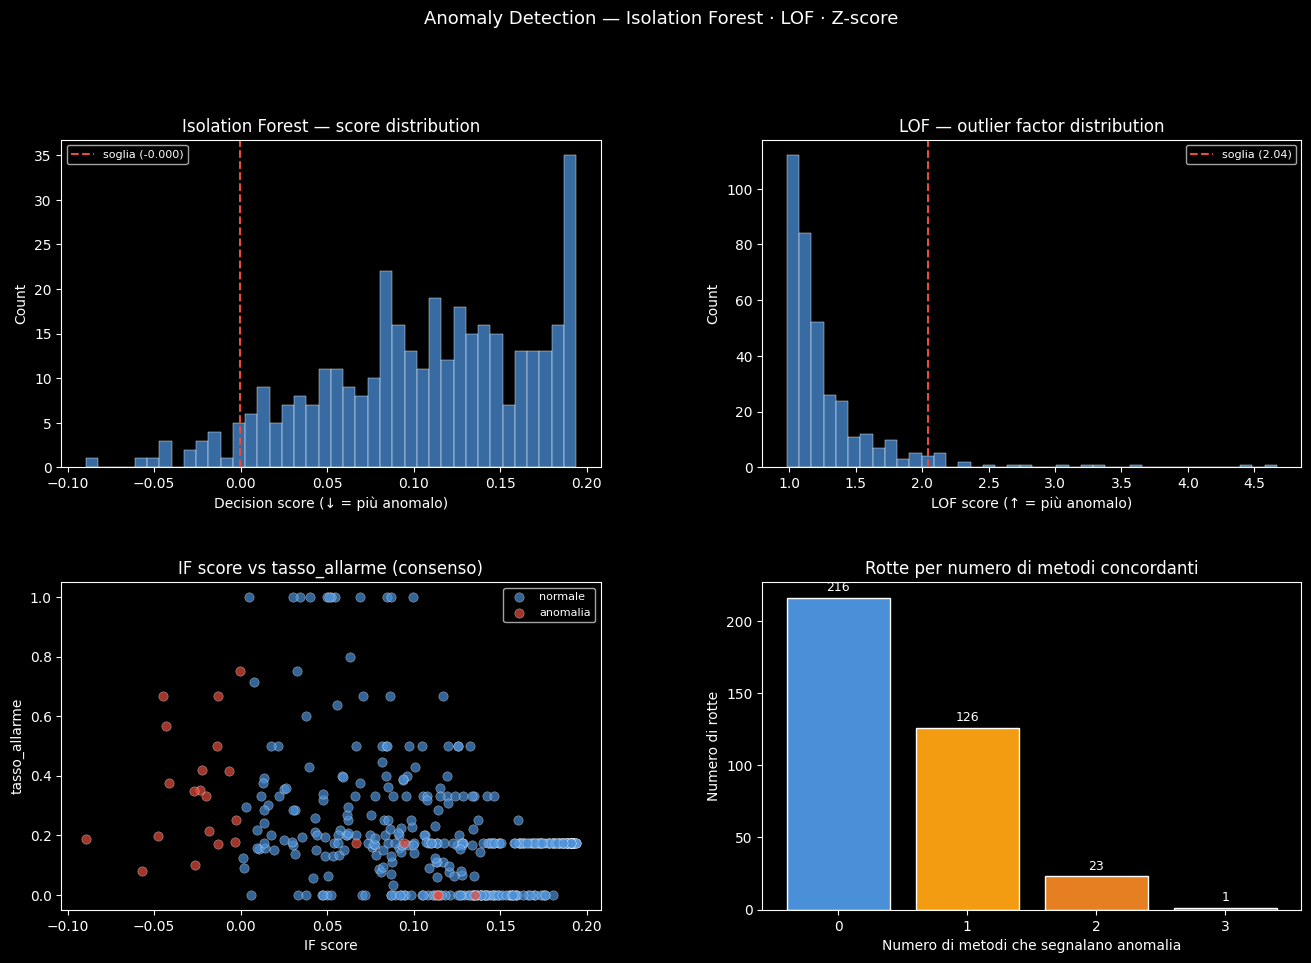

In [670]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

palette = {0: '#4A90D9', 1: '#E74C3C'}

# ── A: Score distribution IF ──────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(df_model['if_score'], bins=40, color='#4A90D9', ax=ax1, edgecolor='white', linewidth=0.3)
thresh_if = df_model.loc[df_model['if_anomaly']==1, 'if_score'].max()
ax1.axvline(thresh_if, color='#E74C3C', lw=1.5, ls='--', label=f'soglia ({thresh_if:.3f})')
ax1.set_title('Isolation Forest — score distribution')
ax1.set_xlabel('Decision score (↓ = più anomalo)')
ax1.legend(fontsize=8)

# ── B: LOF score distribution ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
sns.histplot(df_model['lof_score'], bins=40, color='#4A90D9', ax=ax2, edgecolor='white', linewidth=0.3)
thresh_lof = df_model.loc[df_model['lof_anomaly']==1, 'lof_score'].min()
ax2.axvline(thresh_lof, color='#E74C3C', lw=1.5, ls='--', label=f'soglia ({thresh_lof:.2f})')
ax2.set_title('LOF — outlier factor distribution')
ax2.set_xlabel('LOF score (↑ = più anomalo)')
ax2.legend(fontsize=8)

# ── C: tasso_allarme vs if_score, colorato per consenso ──────────────────────
ax3 = fig.add_subplot(gs[1, 0])
scatter_kw = dict(alpha=0.7, edgecolors='white', linewidths=0.3, s=45)
for label, grp in df_model.groupby('anomaly_consensus'):
    ax3.scatter(grp['if_score'], grp['tasso_allarme'],
                c=palette[label], label=('anomalia' if label else 'normale'), **scatter_kw)
ax3.set_xlabel('IF score')
ax3.set_ylabel('tasso_allarme')
ax3.set_title('IF score vs tasso_allarme (consenso)')
ax3.legend(fontsize=8)

# ── D: Voti per rotta (bar) ──────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
counts = df_model['anomaly_votes'].value_counts().sort_index()
bars = ax4.bar(counts.index.astype(str), counts.values,
               color=['#4A90D9','#F39C12','#E67E22','#E74C3C'][:len(counts)],
               edgecolor='white')
ax4.bar_label(bars, padding=3, fontsize=9)
ax4.set_title('Rotte per numero di metodi concordanti')
ax4.set_xlabel('Numero di metodi che segnalano anomalia')
ax4.set_ylabel('Numero di rotte')
ax4.set_xticks(counts.index.astype(str))

plt.suptitle('Anomaly Detection — Isolation Forest · LOF · Z-score', fontsize=13, y=1.01)
plt.show()

### 6. Abnormal routes — summary table

In [671]:
cols_display = ['AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO',
                'tasso_allarme', 'tot_allarmati', 'tot_investigati',
                'if_anomaly', 'lof_anomaly', 'zscore_anomaly',
                'anomaly_votes', 'if_score', 'lof_score', 'zscore_max']

# Filtra rotte con almeno 1 voto e ordina per n. voti desc, poi tasso_allarme desc
anomaly_table = (
    df_model[df_model['anomaly_votes'] >= 1][cols_display]
    .sort_values(['anomaly_votes', 'tasso_allarme'], ascending=[False, False])
    .reset_index(drop=True)
)

print(f"Rotte con almeno 1 segnalazione: {len(anomaly_table)}")
print(f"Rotte con consenso (≥ 2 metodi):  {df_model['anomaly_consensus'].sum()}")
anomaly_table.style.background_gradient(subset=['anomaly_votes'], cmap='YlOrRd')

Rotte con almeno 1 segnalazione: 150
Rotte con consenso (≥ 2 metodi):  24


,AREOPORTO_PARTENZA,AREOPORTO_ARRIVO,tasso_allarme,tot_allarmati,tot_investigati,if_anomaly,lof_anomaly,zscore_anomaly,anomaly_votes,if_score,lof_score,zscore_max
0,tun,mxp,0.375000,3.000000,8.000000,1,1,1,3,-0.041578,3.036634,16.694233
1,man,vce,0.750000,3.000000,4.000000,1,0,1,2,-0.000400,1.164717,4.183527
2,cmn,blq,0.666667,2.000000,3.000000,1,0,1,2,-0.044645,1.424951,4.180924
3,ist,nap,0.666667,2.000000,3.000000,1,0,1,2,-0.012946,1.317329,4.183527
4,ist,vce,0.565217,13.000000,23.000000,1,0,1,2,-0.043232,1.217006,4.183527
5,dxb,vce,0.500000,1.000000,2.000000,1,0,1,2,-0.013553,1.434711,3.553404
6,saw,bgy,0.418301,64.000000,153.000000,1,0,1,2,-0.022232,1.154723,3.188914
7,ist,mxp,0.415094,22.000000,53.000000,1,0,1,2,-0.006611,1.155379,3.930503
8,ist,fco,0.352941,12.000000,34.000000,1,0,1,2,-0.023313,1.169961,3.540124
9,saw,fco,0.350000,42.000000,120.000000,1,0,1,2,-0.026964,1.378919,6.284286



The table below lists all **150 routes flagged by at least one method**, sorted by number of votes and alarm rate. Routes with ≥ 2 votes are classified as final anomalies.

**Key observations:**

- **TUN → MXP** is the only route flagged by all 3 methods (votes = 3), with an alarm rate of 37.5% and the highest `zscore_max` (16.69) in the dataset — a clear priority for operational review.

- Routes with **votes = 2** split into two distinct profiles:
  - *High alarm rate, low volume* — e.g. MAN→VCE (75%), CMN→BLQ (67%), IST→NAP (67%): few investigated travellers but a disproportionate number of alarms.
  - *Low alarm rate, high volume* — e.g. TIA→BLQ, TIA→BGY, TIA→PSA: hundreds of thousands of travellers investigated, with alarm rates around 18–20% that stand out statistically even if individually modest.

- Several routes with **votes = 1** show `tasso_allarme = 1.0` (100% alarm rate) but very low absolute counts (1–3 travellers). These are flagged by Z-score only and should be treated with caution — a single alarm on a single traveller is statistically extreme but operationally uninformative.

# POST PROCESSING

## Obiettivo

Il post processing riceve in input `df_model` — il dataset di 366 rotte con i risultati
dell'anomaly detection (Isolation Forest, LOF, Z-score) già calcolati.

L'obiettivo è trasformare i 24 segnali anomali con consenso (≥ 2/3 metodi) in un output
operativo: una lista ranked di rotte sospette con livello di rischio, priority score e
note di qualità sui dati.

In [672]:
# Soglie derivate dalla baseline cross-sezionale
SOGLIA_TASSO      = 0.175 * 3   # 3x la mediana → 0.525
SOGLIA_VOLUME     = 100         # almeno 100 investigati per considerare la rotta significativa

# Lavoriamo solo sulle rotte con consenso (≥ 2 metodi su 3)
df_post = df_model[df_model['anomaly_consensus'] == 1].copy()

print(f"Rotte anomale in ingresso: {len(df_post)}")
print(df_post[['AREOPORTO_PARTENZA','AREOPORTO_ARRIVO','tasso_allarme','tot_investigati','anomaly_votes']].to_string())

Rotte anomale in ingresso: 24
    AREOPORTO_PARTENZA AREOPORTO_ARRIVO  tasso_allarme  tot_investigati  anomaly_votes
4                  ala              mxp       0.000000              1.0              2
62                 cmn              blq       0.666667              3.0              2
77                 doh              fco       0.333333              3.0              2
94                 dxb              vce       0.500000              2.0              2
134                ika              mxp       0.251462            171.0              2
138                ist              bri       0.214286             14.0              2
141                ist              fco       0.352941             34.0              2
142                ist              mxp       0.415094             53.0              2
143                ist              nap       0.666667              3.0              2
146                ist              vce       0.565217             23.0              2
171          

In [673]:
def classifica_rischio(row):
    tasso = row['tasso_allarme']
    volume = row['tot_investigati']
    voti = row['anomaly_votes']
    
    # CRITICO: flaggato da tutti e 3 i metodi
    if voti == 3:
        return 'CRITICO'
    
    # ALTO: tasso sopra soglia 3x baseline (0.525) — indipendentemente dal volume
    if tasso >= SOGLIA_TASSO:
        return 'ALTO'
    
   # ALTO: tasso >= 30% con almeno 2 investigati
    if tasso >= 0.30 and volume >= 2:
         return 'ALTO'
    
    # MEDIO: volume enorme con tasso >= 9% (cattura tia→fco al 10%)
    if volume >= SOGLIA_VOLUME and tasso >= 0.09:
        return 'MEDIO'
    
    # MEDIO: tasso >= 20% con volume decente
    if tasso >= 0.20 and volume >= 10:
        return 'MEDIO'
    
    # BASSO: tutto il resto
    return 'BASSO'

df_post['livello_rischio'] = df_post.apply(classifica_rischio, axis=1)

print(df_post['livello_rischio'].value_counts())
print()
print(df_post[['AREOPORTO_PARTENZA','AREOPORTO_ARRIVO','tasso_allarme',
               'tot_investigati','anomaly_votes','livello_rischio']].to_string())

livello_rischio
ALTO       10
MEDIO       7
BASSO       6
CRITICO     1
Name: count, dtype: int64

    AREOPORTO_PARTENZA AREOPORTO_ARRIVO  tasso_allarme  tot_investigati  anomaly_votes livello_rischio
4                  ala              mxp       0.000000              1.0              2           BASSO
62                 cmn              blq       0.666667              3.0              2            ALTO
77                 doh              fco       0.333333              3.0              2            ALTO
94                 dxb              vce       0.500000              2.0              2            ALTO
134                ika              mxp       0.251462            171.0              2           MEDIO
138                ist              bri       0.214286             14.0              2           MEDIO
141                ist              fco       0.352941             34.0              2            ALTO
142                ist              mxp       0.415094             53.0      

In [674]:
def assegna_nota(row):
    tasso = row['tasso_allarme']
    volume = row['tot_investigati']
    
    # Dato incompleto: tasso presente ma zero investigati da df2
    if volume == 0 and tasso > 0:
        return 'dato incompleto — tasso da df1, nessun record in df2'
    
    # Falso positivo probabile: tasso zero, volume minimo
    if tasso == 0 and volume <= 2:
        return 'probabile falso positivo — flaggato per features non legate al tasso'
    
    # Borderline: tasso alto ma volume troppo basso per essere affidabile
    if tasso >= 0.30 and volume <= 3:
        return 'attenzione — tasso alto ma volume insufficiente (≤3 investigati)'
    
    return 'ok'

df_post['nota_qualita'] = df_post.apply(assegna_nota, axis=1)

print(df_post[['AREOPORTO_PARTENZA','AREOPORTO_ARRIVO','tasso_allarme',
               'tot_investigati','livello_rischio','nota_qualita']].to_string())

    AREOPORTO_PARTENZA AREOPORTO_ARRIVO  tasso_allarme  tot_investigati livello_rischio                                                          nota_qualita
4                  ala              mxp       0.000000              1.0           BASSO  probabile falso positivo — flaggato per features non legate al tasso
62                 cmn              blq       0.666667              3.0            ALTO      attenzione — tasso alto ma volume insufficiente (≤3 investigati)
77                 doh              fco       0.333333              3.0            ALTO      attenzione — tasso alto ma volume insufficiente (≤3 investigati)
94                 dxb              vce       0.500000              2.0            ALTO      attenzione — tasso alto ma volume insufficiente (≤3 investigati)
134                ika              mxp       0.251462            171.0           MEDIO                                                                    ok
138                ist              bri       0.2142

In [675]:
from scipy import stats as scipy_stats

# ── PUNTO 1: motivazione falsi positivi ──────────────────────────────────────
feature_cols = [
    'tot_allarmi_chiusi', 'tot_allarmi_generati', 'tot_allarmi_non_chiusi',
    'tot_allarmi_rilevanti', 'tot_altro', 'tot_esito_negativo',
    'tot_mancato_aggiornamento', 'tot_viaggiatori_con_allarmi',
    'tot_viaggiatori_entrati', 'tot_viaggiatori_investigati',
    'tot_voli_con_allarmi', 'tot_voli_disponibili',
    'tot_voli_investigati', 'tot_voli_solo_visualizzati',
    'tot_entrati', 'tot_investigati', 'tot_allarmati',
    'tasso_allarme', 'alert_rate_alb', 'alert_rate_afg',
    'pct_naz_alb', 'pct_naz_afg', 'alert_rate_visto',
    'alert_rate_passaporto', 'alert_rate_permesso', 'alert_rate_carta',
    'pct_segnalato', 'pct_respinto', 'pct_fermato', 'pct_ok'
]

X_full = df_model[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
X_log_full = np.log1p(X_full.values.astype(float))  # .values.astype(float) forza numpy float puro
Z_full = np.abs(scipy_stats.zscore(X_log_full, ddof=1))
Z_df = pd.DataFrame(Z_full, columns=feature_cols, index=df_model.index)

def motivo_flag(row):
    if row['nota_qualita'] != 'probabile falso positivo — flaggato per features non legate al tasso':
        return ''
    idx = row.name
    top = Z_df.loc[idx].sort_values(ascending=False)
    top = top[top > 3.0]
    if len(top) == 0:
        return 'nessuna feature > soglia z=3'
    return 'flaggato per: ' + ', '.join([f'{f} (z={v:.2f})' for f, v in top.items()])

df_post['motivo_flag'] = df_post.apply(motivo_flag, axis=1)

# ── PUNTO 2: intervallo di confidenza Wilson per rotte a basso volume ─────────
def wilson_ci(row):
    n = int(row['tot_investigati'])
    tasso = row['tasso_allarme']
    if n == 0:
        return np.nan, np.nan
    allarmi = round(tasso * n)
    z = 1.96
    centro  = (allarmi + z**2/2) / (n + z**2)
    margine = (z * np.sqrt(allarmi*(n-allarmi)/n + z**2/4)) / (n + z**2)
    return round(max(0, centro - margine), 3), round(min(1, centro + margine), 3)

df_post['ci95_low']  = df_post.apply(lambda r: wilson_ci(r)[0], axis=1)
df_post['ci95_high'] = df_post.apply(lambda r: wilson_ci(r)[1], axis=1)
df_post['ci95_str']  = df_post.apply(
    lambda r: f"[{r['ci95_low']:.1%}, {r['ci95_high']:.1%}]" 
              if pd.notna(r['ci95_low']) else 'n/d', axis=1
)

# Verifica risultati
print(df_post[['AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO', 'tasso_allarme',
               'tot_investigati', 'livello_rischio',
               'nota_qualita', 'motivo_flag', 'ci95_str']].to_string())

    AREOPORTO_PARTENZA AREOPORTO_ARRIVO  tasso_allarme  tot_investigati livello_rischio                                                          nota_qualita                         motivo_flag        ci95_str
4                  ala              mxp       0.000000              1.0           BASSO  probabile falso positivo — flaggato per features non legate al tasso  flaggato per: pct_naz_afg (z=4.96)   [0.0%, 79.3%]
62                 cmn              blq       0.666667              3.0            ALTO      attenzione — tasso alto ma volume insufficiente (≤3 investigati)                                      [20.8%, 93.9%]
77                 doh              fco       0.333333              3.0            ALTO      attenzione — tasso alto ma volume insufficiente (≤3 investigati)                                       [6.1%, 79.2%]
94                 dxb              vce       0.500000              2.0            ALTO      attenzione — tasso alto ma volume insufficiente (≤3 investigati)   

## Risultati della classificazione

| Livello | Rotte | Descrizione |
|---------|-------|-------------|
| 🔴 CRITICO | 1 | Flaggata da tutti e 3 i metodi — priorità assoluta |
| 🟠 ALTO | 10 | Tasso allarme sopra soglia o alto volume con tasso elevato |
| 🟡 MEDIO | 7 | Volume altissimo (rotte TIA) con tasso statisticamente rilevante |
| ⚪ BASSO | 6 | Segnale debole — basso tasso e/o volume insufficiente |

## Note sui dati

- **3 rotte** classificate come probabili falsi positivi: flaggate per concentrazione
  anomala di nazionalità afghana (`pct_naz_afg` z=4.96) ma con tasso allarme = 0%
- **2 rotte** con dato incompleto: tasso presente in df1 ma nessun record in df2
- **5 rotte ALTO** con volume ≤ 3 investigati: tasso osservato alto ma intervallo
  di confidenza molto largo — da trattare con cautela operativa

In [676]:
# ── PRIORITY SCORE CORRETTO — 60% tasso, 40% allarmi assoluti log ─────────────

# ── Tutte le 24 rotte ────────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler
scaler_pp3 = MinMaxScaler()

df_post['allarmi_assoluti'] = df_post['tasso_allarme'] * df_post['tot_investigati']
df_post['allarmi_assoluti_log'] = np.log1p(df_post['allarmi_assoluti'])

cols_score3 = ['tasso_allarme', 'allarmi_assoluti_log']
df_post[['tasso_norm', 'allarmi_norm']] = scaler_pp3.fit_transform(
    df_post[cols_score3]
)

df_post['priority_score'] = (
    0.60 * df_post['tasso_norm'] +
    0.40 * df_post['allarmi_norm']
).round(4)

df_post = df_post.sort_values(
    ['livello_rischio', 'priority_score'], ascending=[True, False]
).reset_index(drop=True)
df_post['rank'] = df_post.index + 1

# ── Stampa risultati ─────────────────────────────────────────────────────────
print("=== TUTTE LE 24 ROTTE (pesi: tasso 60%, allarmi 40%) ===")
print(df_post[['rank', 'AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO', 'PAESE_PART',
               'tasso_allarme', 'allarmi_assoluti', 'tot_investigati',
               'livello_rischio', 'priority_score',
               'ci95_str', 'nota_qualita']].to_string())

=== TUTTE LE 24 ROTTE (pesi: tasso 60%, allarmi 40%) ===
    rank AREOPORTO_PARTENZA AREOPORTO_ARRIVO           PAESE_PART  tasso_allarme  allarmi_assoluti  tot_investigati livello_rischio  priority_score        ci95_str                                                          nota_qualita
0      1                man              vce          regno unito       0.750000               3.0              4.0            ALTO          0.6658  [30.1%, 95.4%]                                                                    ok
1      2                cmn              blq              marocco       0.666667               2.0              3.0            ALTO          0.5855  [20.8%, 93.9%]      attenzione — tasso alto ma volume insufficiente (≤3 investigati)
2      3                ist              nap              turchia       0.666667               2.0              3.0            ALTO          0.5855  [20.8%, 93.9%]      attenzione — tasso alto ma volume insufficiente (≤3 investigati)
3      

In [677]:
# ── Solo 19 rotte affidabili ─────────────────────────────────────────────────
note_escluse = [
    'probabile falso positivo — flaggato per features non legate al tasso',
    'dato incompleto — tasso da df1, nessun record in df2'
]
df_post_clean = df_post[~df_post['nota_qualita'].isin(note_escluse)].copy()

scaler_clean3 = MinMaxScaler()
df_post_clean['allarmi_assoluti'] = df_post_clean['tasso_allarme'] * df_post_clean['tot_investigati']
df_post_clean['allarmi_assoluti_log'] = np.log1p(df_post_clean['allarmi_assoluti'])

cols_score3 = ['tasso_allarme', 'allarmi_assoluti_log']
df_post_clean[['tasso_norm', 'allarmi_norm']] = scaler_clean3.fit_transform(
    df_post_clean[cols_score3]
)

df_post_clean['priority_score'] = (
    0.60 * df_post_clean['tasso_norm'] +
    0.40 * df_post_clean['allarmi_norm']
).round(4)

df_post_clean = df_post_clean.sort_values(
    ['livello_rischio', 'priority_score'], ascending=[True, False]
).reset_index(drop=True)
df_post_clean['rank'] = df_post_clean.index + 1

print("\n=== 19 ROTTE AFFIDABILI (pesi: tasso 60%, allarmi 40%) ===")
print(df_post_clean[['rank', 'AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO', 'PAESE_PART',
                      'tasso_allarme', 'allarmi_assoluti', 'tot_investigati',
                      'livello_rischio', 'priority_score',
                      'ci95_str', 'nota_qualita']].to_string())


=== 19 ROTTE AFFIDABILI (pesi: tasso 60%, allarmi 40%) ===
    rank AREOPORTO_PARTENZA AREOPORTO_ARRIVO           PAESE_PART  tasso_allarme  allarmi_assoluti  tot_investigati livello_rischio  priority_score        ci95_str                                                      nota_qualita
0      1                man              vce          regno unito       0.750000               3.0              4.0            ALTO          0.6358  [30.1%, 95.4%]                                                                ok
1      2                cmn              blq              marocco       0.666667               2.0              3.0            ALTO          0.5465  [20.8%, 93.9%]  attenzione — tasso alto ma volume insufficiente (≤3 investigati)
2      3                ist              nap              turchia       0.666667               2.0              3.0            ALTO          0.5465  [20.8%, 93.9%]  attenzione — tasso alto ma volume insufficiente (≤3 investigati)
3      4            

# Priority Score
È un numero tra 0 e 1 che riassume in un solo valore quanto una rotta è prioritaria operativamente. È costruito combinando 3 componenti con pesi diversi:

60% → tasso_allarme — quanti % di passeggeri generano allarme

40% → allarmi_assoluti (log) — quanti allarmi reali in numeri assoluti



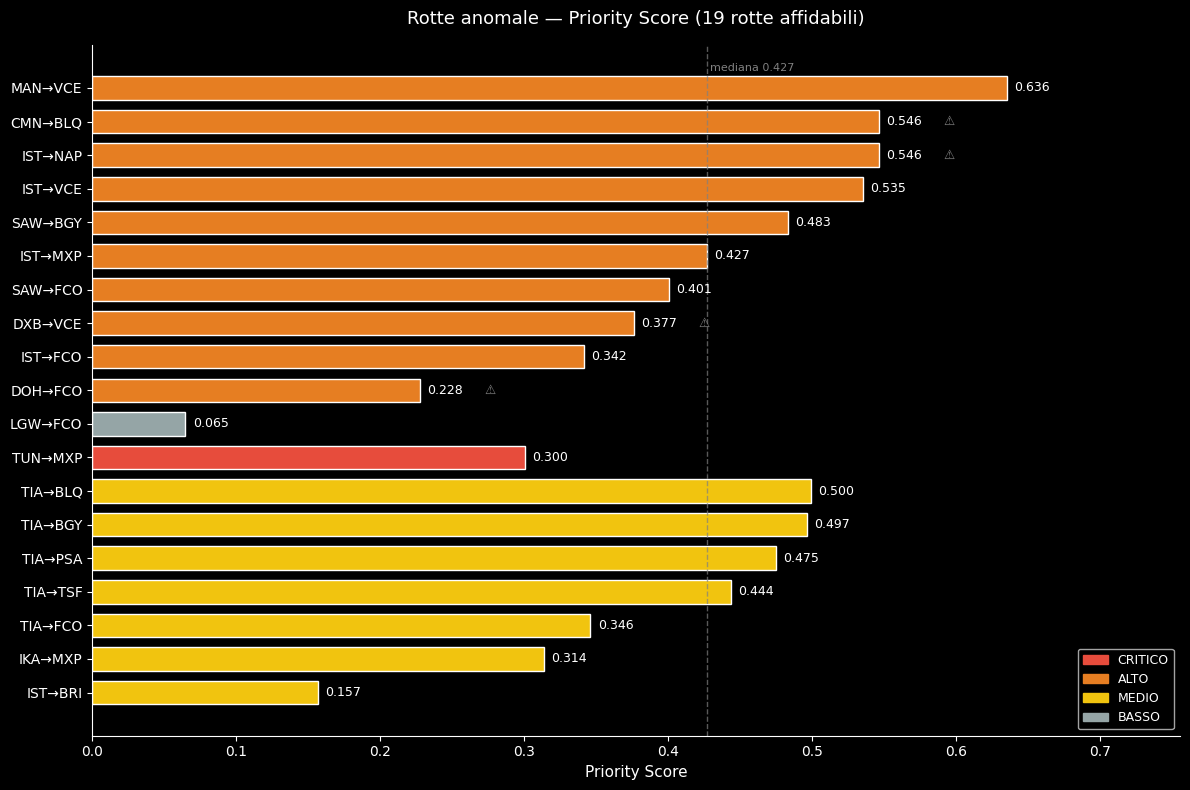

Grafico salvato come priority_score.png


In [678]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Colori per livello rischio
color_map = {
    'CRITICO': '#E74C3C',
    'ALTO':    '#E67E22',
    'MEDIO':   '#F1C40F',
    'BASSO':   '#95A5A6'
}

fig, ax = plt.subplots(figsize=(12, 8))

# Ordine invertito per avere rank 1 in alto
df_plot = df_post_clean.sort_values('rank', ascending=False)

labels = df_plot['AREOPORTO_PARTENZA'].str.upper() + '→' + df_plot['AREOPORTO_ARRIVO'].str.upper()
scores = df_plot['priority_score']
colors = df_plot['livello_rischio'].map(color_map)
ranks  = df_plot['rank']

bars = ax.barh(range(len(df_plot)), scores, color=colors, edgecolor='white', height=0.7)

# Etichette sui bar
for i, (score, nota, rank) in enumerate(zip(scores, df_plot['nota_qualita'], ranks)):
    ax.text(score + 0.005, i, f'{score:.3f}', va='center', fontsize=9)
    if nota == 'attenzione — tasso alto ma volume insufficiente (≤3 investigati)':
        ax.text(score + 0.045, i, '⚠', va='center', fontsize=9, color='gray')

# Asse Y con etichette rotta
ax.set_yticks(range(len(df_plot)))
ax.set_yticklabels(labels, fontsize=10)

# Linea soglia mediana
mediana_score = df_post_clean['priority_score'].median()
ax.axvline(mediana_score, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.text(mediana_score + 0.002, len(df_plot) - 0.5,
        f'mediana {mediana_score:.3f}', fontsize=8, color='gray')

# Separatori tra livelli
livelli = df_plot['livello_rischio'].values
for i in range(1, len(livelli)):
    if livelli[i] != livelli[i-1]:
        ax.axhline(i - 0.5, color='black', linewidth=0.8, alpha=0.3, linestyle='-')

# Legenda
patches = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)

ax.set_xlabel('Priority Score', fontsize=11)
ax.set_title('Rotte anomale — Priority Score (19 rotte affidabili)', fontsize=13, pad=15)
ax.set_xlim(0, max(scores) + 0.12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('priority_score.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato come priority_score.png")

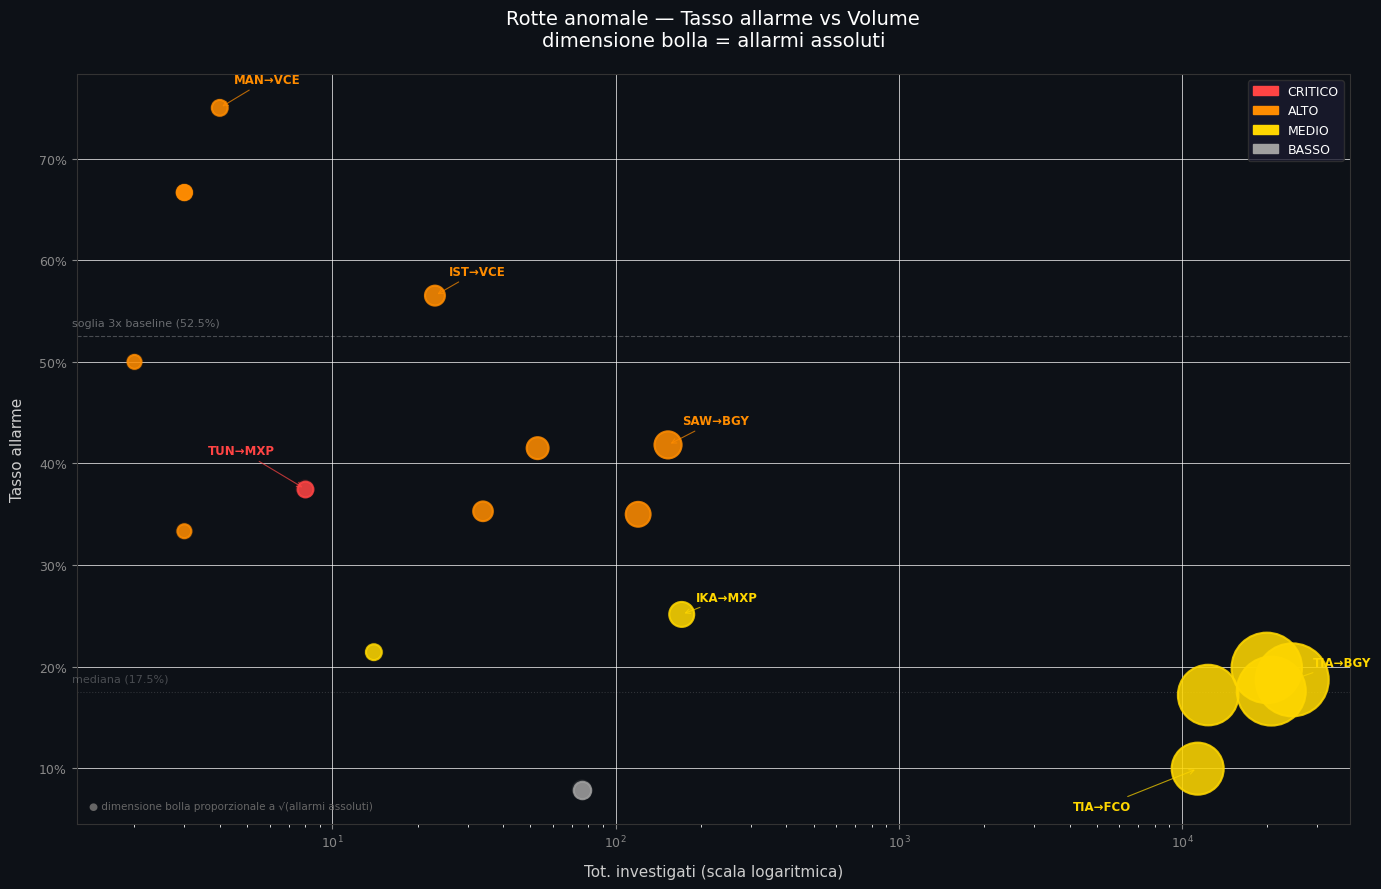

Grafico salvato come bubble_chart_dark.png


In [679]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Sfondo scuro
plt.style.use('dark_background')

color_map = {
    'CRITICO': '#FF4444',
    'ALTO':    '#FF8C00',
    'MEDIO':   '#FFD700',
    'BASSO':   '#A0A0A0'
}

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')

# Griglia sottile
ax.grid(True, color='#ffffff15', linewidth=0.5, zorder=0)

# ── Bolle ────────────────────────────────────────────────────────────────────
for livello in ['BASSO', 'MEDIO', 'ALTO', 'CRITICO']:
    subset = df_post_clean[df_post_clean['livello_rischio'] == livello]
    
    # Bolla principale
    ax.scatter(
        subset['tot_investigati'],
        subset['tasso_allarme'],
        s=np.sqrt(subset['allarmi_assoluti'].clip(lower=1)) * 40 + 60,
        c=color_map[livello],
        alpha=0.85,
        edgecolors=color_map[livello],
        linewidths=1.5,
        label=livello,
        zorder=3
    )
    # Alone luminoso
    ax.scatter(
        subset['tot_investigati'],
        subset['tasso_allarme'],
        s=np.sqrt(subset['allarmi_assoluti'].clip(lower=1)) * 40 + 120,
        c=color_map[livello],
        alpha=0.12,
        edgecolors='none',
        zorder=2
    )

# ── Annotazioni selettive con frecce ─────────────────────────────────────────
annotazioni = {
    'tun': {'arr': 'mxp', 'xytext': (-60, 20)},
    'man': {'arr': 'vce', 'xytext': (10, 20)},
    'ist': {'arr': 'vce', 'xytext': (10, 15)},
    'saw': {'arr': 'bgy', 'xytext': (10, 15)},
    'tia': {'arr': 'bgy', 'xytext': (10, -25)},
    'tia': {'arr': 'fco', 'xytext': (-80, -30)},
}

rotte_da_annotare = [
    ('tun', 'mxp', (-70, 25)),
    ('man', 'vce', (10, 18)),
    ('ist', 'vce', (10, 15)),
    ('saw', 'bgy', (10, 15)),
    ('tia', 'bgy', (15, 10)),
    ('tia', 'fco', (-90, -30)),
    ('ika', 'mxp', (10, 10)),
]

for part, arr, offset in rotte_da_annotare:
    row = df_post_clean[
        (df_post_clean['AREOPORTO_PARTENZA'] == part) &
        (df_post_clean['AREOPORTO_ARRIVO'] == arr)
    ]
    if len(row) == 0:
        continue
    row = row.iloc[0]
    livello = row['livello_rischio']
    label = f"{part.upper()}→{arr.upper()}"

    ax.annotate(
        label,
        xy=(row['tot_investigati'], row['tasso_allarme']),
        xytext=offset,
        textcoords='offset points',
        fontsize=8.5,
        color=color_map[livello],
        fontweight='bold',
        arrowprops=dict(
            arrowstyle='->',
            color=color_map[livello],
            lw=0.8,
            alpha=0.7
        ),
        zorder=5
    )

# ── Linee di riferimento ─────────────────────────────────────────────────────
ax.axhline(0.525, color='#ffffff40', linestyle='--', linewidth=0.8)
ax.text(1.2, 0.535, 'soglia 3x baseline (52.5%)',
        fontsize=8, color='#ffffff60')

ax.axhline(0.175, color='#ffffff25', linestyle=':', linewidth=0.8)
ax.text(1.2, 0.185, 'mediana (17.5%)',
        fontsize=8, color='#ffffff40')

# ── Assi e titolo ─────────────────────────────────────────────────────────────
ax.set_xlabel('Tot. investigati (scala logaritmica)',
              fontsize=11, color='#cccccc', labelpad=10)
ax.set_ylabel('Tasso allarme',
              fontsize=11, color='#cccccc', labelpad=10)
ax.set_title('Rotte anomale — Tasso allarme vs Volume\n'
             'dimensione bolla = allarmi assoluti',
             fontsize=14, color='white', pad=20)

ax.set_xscale('log')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.tick_params(colors='#888888', labelsize=9)
for spine in ax.spines.values():
    spine.set_color('#333333')

# ── Legenda ───────────────────────────────────────────────────────────────────
patches = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
legend = ax.legend(
    handles=patches,
    fontsize=9,
    loc='upper right',
    facecolor='#1a1a2e',
    edgecolor='#333333',
    labelcolor='white'
)

# ── Nota dimensione bolle ─────────────────────────────────────────────────────
ax.text(0.01, 0.02,
        '● dimensione bolla proporzionale a √(allarmi assoluti)',
        transform=ax.transAxes,
        fontsize=7.5, color='#666666')

plt.tight_layout()
plt.savefig('bubble_chart_dark.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("Grafico salvato come bubble_chart_dark.png")

In [680]:
# ── REPORT FINALE ─────────────────────────────────────────────────────────────
from datetime import date

oggi = date.today().strftime('%d/%m/%Y')

print("=" * 70)
print("       TRANSIT ANOMALY REPORT — POST PROCESSING")
print(f"       Data: {oggi}")
print("=" * 70)

# ── Sommario ──────────────────────────────────────────────────────────────────
print(f"""
SOMMARIO
--------
Rotte totali analizzate:          366
Rotte con segnale anomalo (≥1):   150
Rotte con consenso (≥2/3):         24
Rotte affidabili nel report:       19
Rotte escluse (qualità dati):       5

Distribuzione per livello di rischio (24 rotte con consenso):
  CRITICO : {len(df_post[df_post['livello_rischio']=='CRITICO'])}
  ALTO    : {len(df_post[df_post['livello_rischio']=='ALTO'])}
  MEDIO   : {len(df_post[df_post['livello_rischio']=='MEDIO'])}
  BASSO   : {len(df_post[df_post['livello_rischio']=='BASSO'])}  (di cui 5 con problemi di qualità dati)

Baseline di riferimento (data preparation):
  Mediana tasso_allarme : 0.175
  Soglia operativa 3x   : 0.525

Priority score:
  Metodo : tasso_allarme 60% + allarmi_assoluti_log 40%
  Nota   : anomaly_votes escluso — quasi costante (=2) su tutte le rotte
           tranne TUN→MXP (=3) già separata come CRITICO
""")

# ── Sezione 1: Rotte affidabili ───────────────────────────────────────────────
print("=" * 70)
print("SEZIONE 1 — ROTTE AFFIDABILI (19)")
print("Ordinate per livello di rischio e priority score decrescente")
print("=" * 70)

for livello in ['CRITICO', 'ALTO', 'MEDIO', 'BASSO']:
    subset = df_post_clean[df_post_clean['livello_rischio'] == livello]
    if len(subset) == 0:
        continue
    print(f"\n{'─'*70}")
    print(f"  {livello} ({len(subset)} rotte)")
    print(f"{'─'*70}")
    for _, row in subset.iterrows():
        print(f"\n  Rank #{int(row['rank']):02d} — "
              f"{row['AREOPORTO_PARTENZA'].upper()}→"
              f"{row['AREOPORTO_ARRIVO'].upper()} "
              f"({row['PAESE_PART'].title()})")
        print(f"  Tasso allarme    : {row['tasso_allarme']:.1%}  "
              f"IC 95% {row['ci95_str']}")
        print(f"  Investigati      : {int(row['tot_investigati']):,}")
        print(f"  Allarmi assoluti : {int(row['allarmi_assoluti']):,}")
        print(f"  Voti modelli     : {int(row['anomaly_votes'])}/3  "
              f"(IF={int(row['if_anomaly'])} "
              f"LOF={int(row['lof_anomaly'])} "
              f"Z={int(row['zscore_anomaly'])})")
        print(f"  Priority score   : {row['priority_score']:.4f}")
        if row['nota_qualita'] != 'ok':
            print(f"  ⚠ Nota           : {row['nota_qualita']}")

# ── Sezione 2: Rotte escluse ──────────────────────────────────────────────────
print(f"\n{'='*70}")
print("SEZIONE 2 — ROTTE ESCLUSE (5)")
print("Rotte con consenso ma escluse per problemi di qualità dati")
print(f"{'='*70}")

note_escluse = [
    'probabile falso positivo — flaggato per features non legate al tasso',
    'dato incompleto — tasso da df1, nessun record in df2'
]
df_escluse = df_post[df_post['nota_qualita'].isin(note_escluse)]

for _, row in df_escluse.iterrows():
    paese = row['PAESE_PART'].title() if pd.notna(row['PAESE_PART']) else 'n/d'
    print(f"\n  {row['AREOPORTO_PARTENZA'].upper()}→"
          f"{row['AREOPORTO_ARRIVO'].upper()} ({paese})")
    print(f"  Livello          : {row['livello_rischio']}")
    print(f"  Motivo esclusione: {row['nota_qualita']}")
    if pd.notna(row['motivo_flag']) and row['motivo_flag'] != '':
        print(f"  Dettaglio        : {row['motivo_flag']}")

# ── Elimina colonne intermedie di calcolo ─────────────────────────────────────
cols_intermedie = ['voti_norm', 'tasso_norm', 'allarmi_norm', 'allarmi_assoluti_log']
df_post = df_post.drop(columns=cols_intermedie, errors='ignore')
df_post_clean = df_post_clean.drop(columns=cols_intermedie, errors='ignore')

# ── Export ────────────────────────────────────────────────────────────────────
df_post.to_csv('report_24_rotte.csv', index=False)
df_post_clean.to_csv('report_19_rotte_affidabili.csv', index=False)

print("Export completato:")
print(f"  → report_24_rotte.csv            ({len(df_post)} rotte, {df_post.shape[1]} colonne)")
print(f"  → report_19_rotte_affidabili.csv ({len(df_post_clean)} rotte, {df_post_clean.shape[1]} colonne)")
print("=" * 70)

       TRANSIT ANOMALY REPORT — POST PROCESSING
       Data: 31/03/2026

SOMMARIO
--------
Rotte totali analizzate:          366
Rotte con segnale anomalo (≥1):   150
Rotte con consenso (≥2/3):         24
Rotte affidabili nel report:       19
Rotte escluse (qualità dati):       5

Distribuzione per livello di rischio (24 rotte con consenso):
  CRITICO : 1
  ALTO    : 10
  MEDIO   : 7
  BASSO   : 6  (di cui 5 con problemi di qualità dati)

Baseline di riferimento (data preparation):
  Mediana tasso_allarme : 0.175
  Soglia operativa 3x   : 0.525

Priority score:
  Metodo : tasso_allarme 60% + allarmi_assoluti_log 40%
  Nota   : anomaly_votes escluso — quasi costante (=2) su tutte le rotte
           tranne TUN→MXP (=3) già separata come CRITICO

SEZIONE 1 — ROTTE AFFIDABILI (19)
Ordinate per livello di rischio e priority score decrescente

──────────────────────────────────────────────────────────────────────
  CRITICO (1 rotte)
──────────────────────────────────────────────────────────